# Meta-Analysis of RAG Output

## Libraries Imported

In [145]:
import pandas as pd
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer

## Data Import and Transformation

### Data Import

In [146]:
# load the responses from the JSON file
with open('./output.json', 'r') as f:
    responses = json.load(f)


### Structuring the JSON File

In [147]:
def parse_q_string(q_string):
    parts = {}
    for field in ["QuestionText", "ShortAnswer", "Reasoning", "Evidence"]:
        # Match the value starting at the label and ending at the next label or end of string
        pattern = rf"{field}:\s*(.*?)(?=(QuestionText:|ShortAnswer:|Reasoning:|Evidence:|$))"
        match = re.search(pattern, q_string, re.DOTALL)
        if match:
            parts[field] = match.group(1).strip().rstrip(",")  # remove trailing comma if any
        else:
            parts[field] = 'Unfilled'
    return parts

In [148]:
for key in responses.keys():
    for question, answer in responses[key]['answers'].items():
        if type(answer) == str:
            responses[key]['answers'][question] = parse_q_string(answer)

In [149]:
for key in responses.keys():
    for question, answer in responses[key]['answers'].items():
        if type(answer) == str:
            responses = parse_q_string(answer)
            print("k:")
            print(k)
            print(f"id: {key} and title {responses[key]['metadata']['Title']}")
            break

### Flattening JSON File

In [150]:
def flattenDict(d, parent_key='', sep='-'):
    """
    Flattens a nested dictionary.

    Args:
        d (dict): The nested dictionary to flatten.
        parent_key (str): The parent key to use for the flattened dictionary.
        sep (str): The separator to use for the flattened dictionary.

    Returns:
        dict: The flattened dictionary.
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flattenDict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

def flattenJson(json):
    """
    Flattens a response json.

    Args:
        json (dict): The response json to flatten.

    Returns:
        dict: The flattened response json.
    """
    newJson={}
    for k,v in json.items():
        newJson[k]={}
        for k2,v2 in v.items():
            if isinstance(v2,dict):
                newJson[k].update(flattenDict(v2))
            else:
                newJson[k][k2]=v2
    return newJson

In [151]:
flat_responses=flattenJson(responses)

### Converting JSON File to Pandas Dataframe

In [152]:
# convert the json to a pandas dataframe
df = pd.DataFrame.from_dict(flat_responses, orient='index')
df.set_index('paper_id', inplace=True)

In [153]:
# filter out record where "Key" is ""
# cited_df = df[df["Key"] != ""]
cited_df = df

## Distribution of Values for Each Question

In [154]:
general_df = cited_df

# Check if any column contains lists
for col in general_df.columns:
    if general_df[col].apply(lambda x: isinstance(x, list)).any():
        def safe_join(x):
            if isinstance(x, list):
                try:
                    return ", ".join(str(item) for item in x)
                except Exception as e:
                    print(f"Error in column '{col}': {x} ({type(x)})")
                    raise
            return x

        general_df[col] = general_df[col].apply(safe_join)

In [155]:

answers_df = general_df[[
    "year",
    "Q1-ShortAnswer", 
    "Q2-ShortAnswer", 
    "Q3-ShortAnswer", 
    "Q4-ShortAnswer", 
    "Q5-ShortAnswer", 
    "Q6-ShortAnswer", 
    "Q7-ShortAnswer",
    "Q8-ShortAnswer",
    "Q9-ShortAnswer",
    "Q10-ShortAnswer",
    "Q11-ShortAnswer",
    "Q12-ShortAnswer",
    "Q13-ShortAnswer",
    "Q14-ShortAnswer",
    "Q15-ShortAnswer",
    "Q16-ShortAnswer",
    "Q17-ShortAnswer",
    "Q18-ShortAnswer",
    "Q19-ShortAnswer",
    "Q20-ShortAnswer",
    "Q21-ShortAnswer",
    "Q22-ShortAnswer",
    "Q23-ShortAnswer",
    "Q24-ShortAnswer",
    "Q25-ShortAnswer",
    "Q26-ShortAnswer",
    "Q27-ShortAnswer",
]]

answers_df.columns = [
    "Year",
    "New Definition Robustness",
    "Robustness Definition Explicit", 
    "DBMS Component", 
    "Query Optimization Robustness",
    "Theoretical Advancements",
    "Significant Experimentation",
    "Evaluation Type", 
    "Improve Robustness",
    "Technique Proposed", 
    "Metric Used", 
    "Benchmark Used",
    "Source Type", 
    "Controlled Features",
    "Evalaute Robustness",
    "ML Usage",
    "Task Type", 
    "Learning Paradigm",
    "Deep Learning Usage",
    "Transfer Learning", 
    "Data Generation", 
    "Input Encoding", 
    "Uncertainty Evaluation",
    "Generalization to OOD",
    "OOD Evaluation", 
    "Architecture Used",
    "Robustness Main Motivation",
    "Other methods Used"
]
answers_df=answers_df.reset_index(drop=True)

multi_label_cols = [
    col for col in answers_df.columns
    if answers_df[col].astype(str).str.contains(',').any()
]

multi_label_cols.extend(['DBMS Component','OOD Evaluation', 'Uncertainty Evaluation', 'Task Type', 'Learning Paradigm'])

for col in answers_df:
    if col in multi_label_cols:
        answers_df[col] = (
            answers_df[col]
            .astype(str)
            .str.upper()
            .str.split(r',\s*')
        )


encoded_dfs = []

for col in multi_label_cols:
    mlb = MultiLabelBinarizer()
    encoded = pd.DataFrame(
        mlb.fit_transform(answers_df[col]),
        columns=[f"{col}_{cls}" for cls in mlb.classes_],  
        index=answers_df.index
    )
    encoded_dfs.append(encoded)
    
answers_df_encoded = pd.concat([answers_df.drop(columns=multi_label_cols)] + encoded_dfs, axis=1)


### Bar plot Function for Individual Variables

In [156]:
def plot_multilabel_distribution(df, prefix, title):
    cols = [col for col in df.columns if col.startswith(prefix + "_")]
    freq = df[cols].sum().sort_values(ascending=False)
    freq.index = freq.index.str.replace(prefix + "_", "")

    plt.figure(figsize=(8, 4))
    plt.bar(freq.index, freq.values)
    plt.xlabel(prefix)
    plt.ylabel("Number of Studies")
    plt.title(title)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


### Plot Relations with Multiclass Variables

In [157]:
def plot_multilabel_relation_explode(df, col_x, col_y, top_n=None, figsize=(12,8)):
    df_x = df[[col_x]].explode(col_x)
    df_y = df[[col_y]].explode(col_y)

    combined = df_x.merge(df_y, left_index=True, right_index=True)

    if top_n is not None:
        top_labels = combined[col_x].value_counts().nlargest(top_n).index
        combined = combined[combined[col_x].isin(top_labels)]

    # Plot
    plt.figure(figsize=figsize)
    sns.countplot(data=combined, y=col_x, hue=col_y, order=combined[col_x].value_counts().index)
    plt.xlabel("Count")
    plt.ylabel(col_x)
    plt.title(f"{col_y} per {col_x}")
    plt.tight_layout()
    plt.show()

## Analysis on Targeted DBMS Components

### DBMS Components Targeted Over Time

In [158]:
for c in answers_df_encoded.columns:
    print(c)

Year
New Definition Robustness
Robustness Definition Explicit
Query Optimization Robustness
Theoretical Advancements
Significant Experimentation
Improve Robustness
Source Type
Evalaute Robustness
ML Usage
Deep Learning Usage
Transfer Learning
Generalization to OOD
Robustness Main Motivation
Evaluation Type_EMPIRICAL EVALUATION
Evaluation Type_EXPERIMENTAL RESULTS
Evaluation Type_THEORETICAL ANALYSIS
Evaluation Type_UNSURE
Technique Proposed_A COMPREHENSIVE FRAMEWORK FOR ADAPTING CARDINALITY ESTIMATORS
Technique Proposed_ADAPTIVE SAMPLING VIA CROSS-VALIDATION
Technique Proposed_ADAPTIVE SELECTIVITY ESTIMATION (ASE) WITH FIXED-VALUE WEIGHTS AND CONTROLLED FEEDBACK FORGETTING
Technique Proposed_ALECE WITH DATA FEATURIZATION AND ATTENTION MECHANISMS
Technique Proposed_AND FLEXIBLE ADAPTATION TECHNIQUES
Technique Proposed_AND LOG TRANSFORMATION
Technique Proposed_ANOREXIC REDUCTION AND PLAN BOUQUETS
Technique Proposed_BANDIT OPTIMIZER (BAO) USING REINFORCEMENT LEARNING
Technique Proposed_BA

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3941772246.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


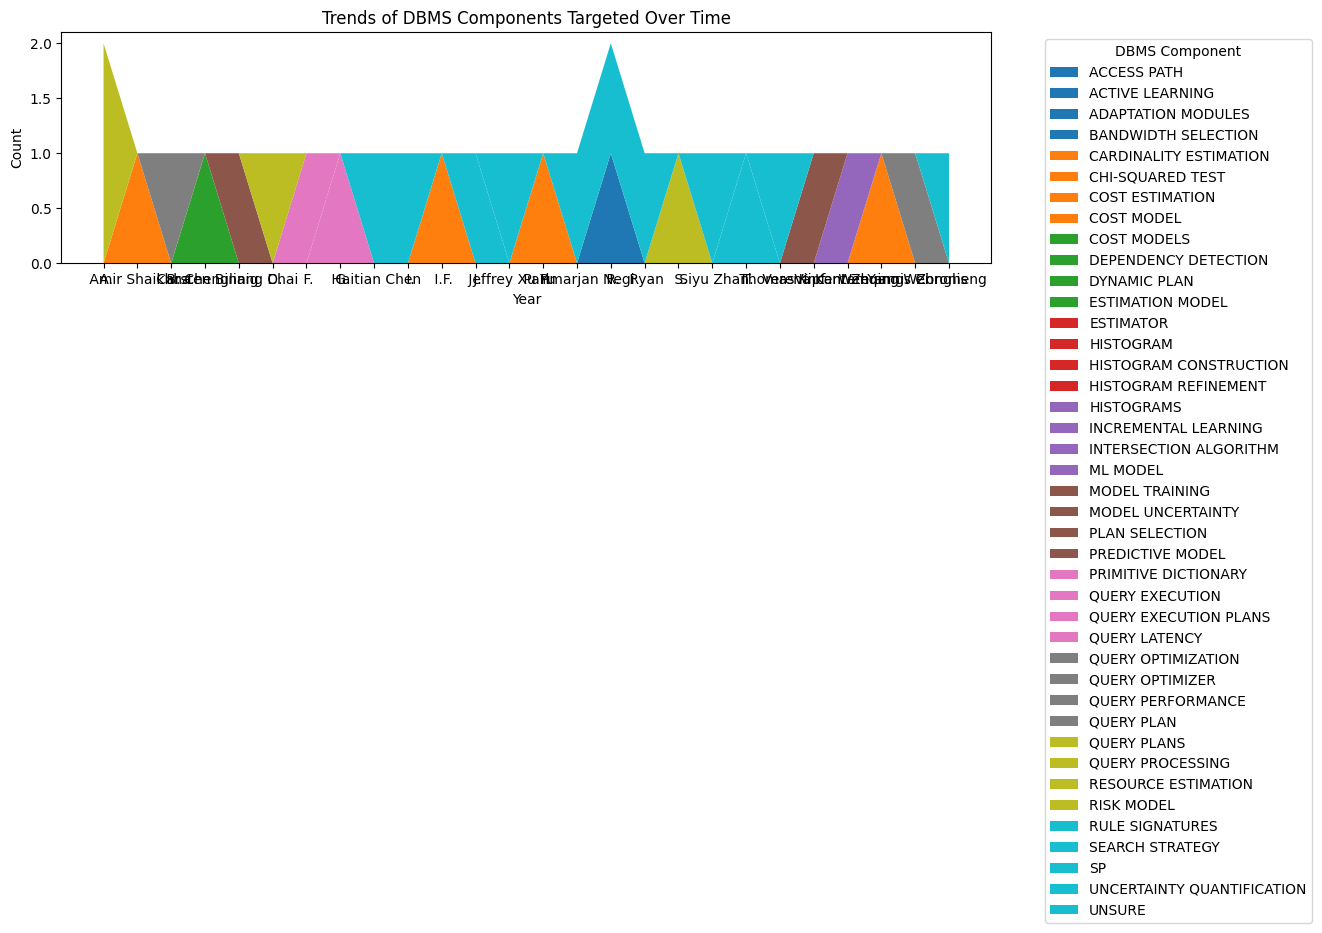

In [159]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('DBMS Component_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('DBMS Component_', '') if x.startswith('DBMS Component_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of DBMS Components Targeted Over Time")
plt.legend(title="DBMS Component", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of DBMS Components Targeted

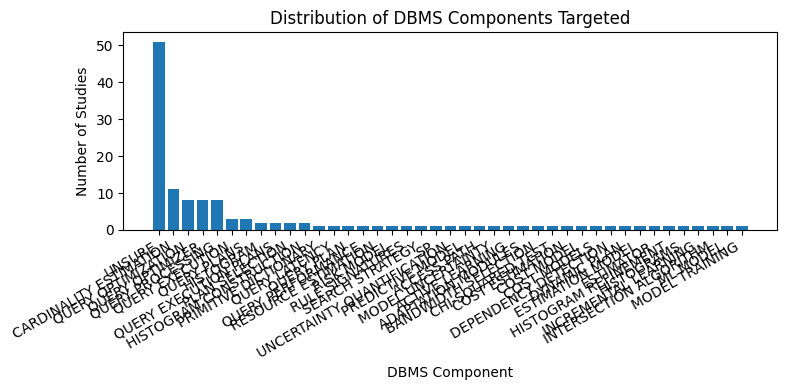

In [160]:
plot_multilabel_distribution(answers_df_encoded, "DBMS Component", "Distribution of DBMS Components Targeted")

### DBMS Components Targeted vs Type of Evaluation

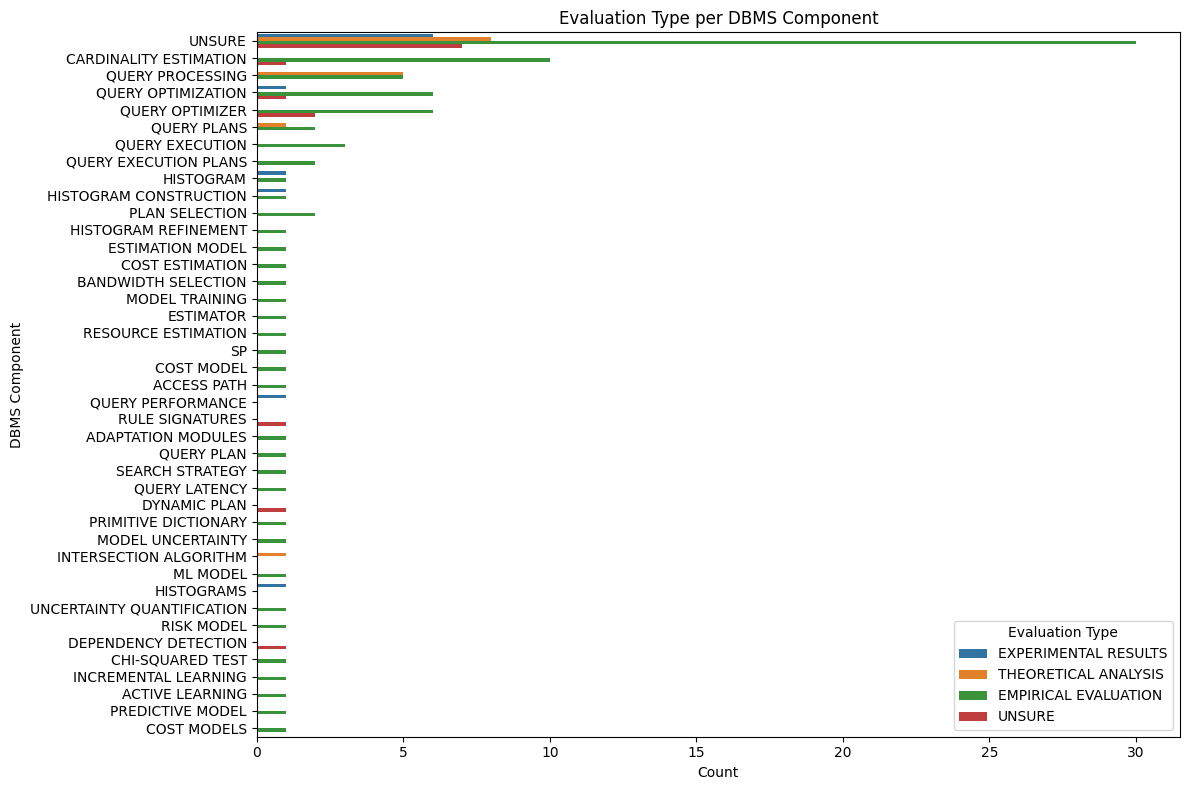

In [161]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Evaluation Type"
)

### DBMS Components Targeted vs Technique Proposed

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


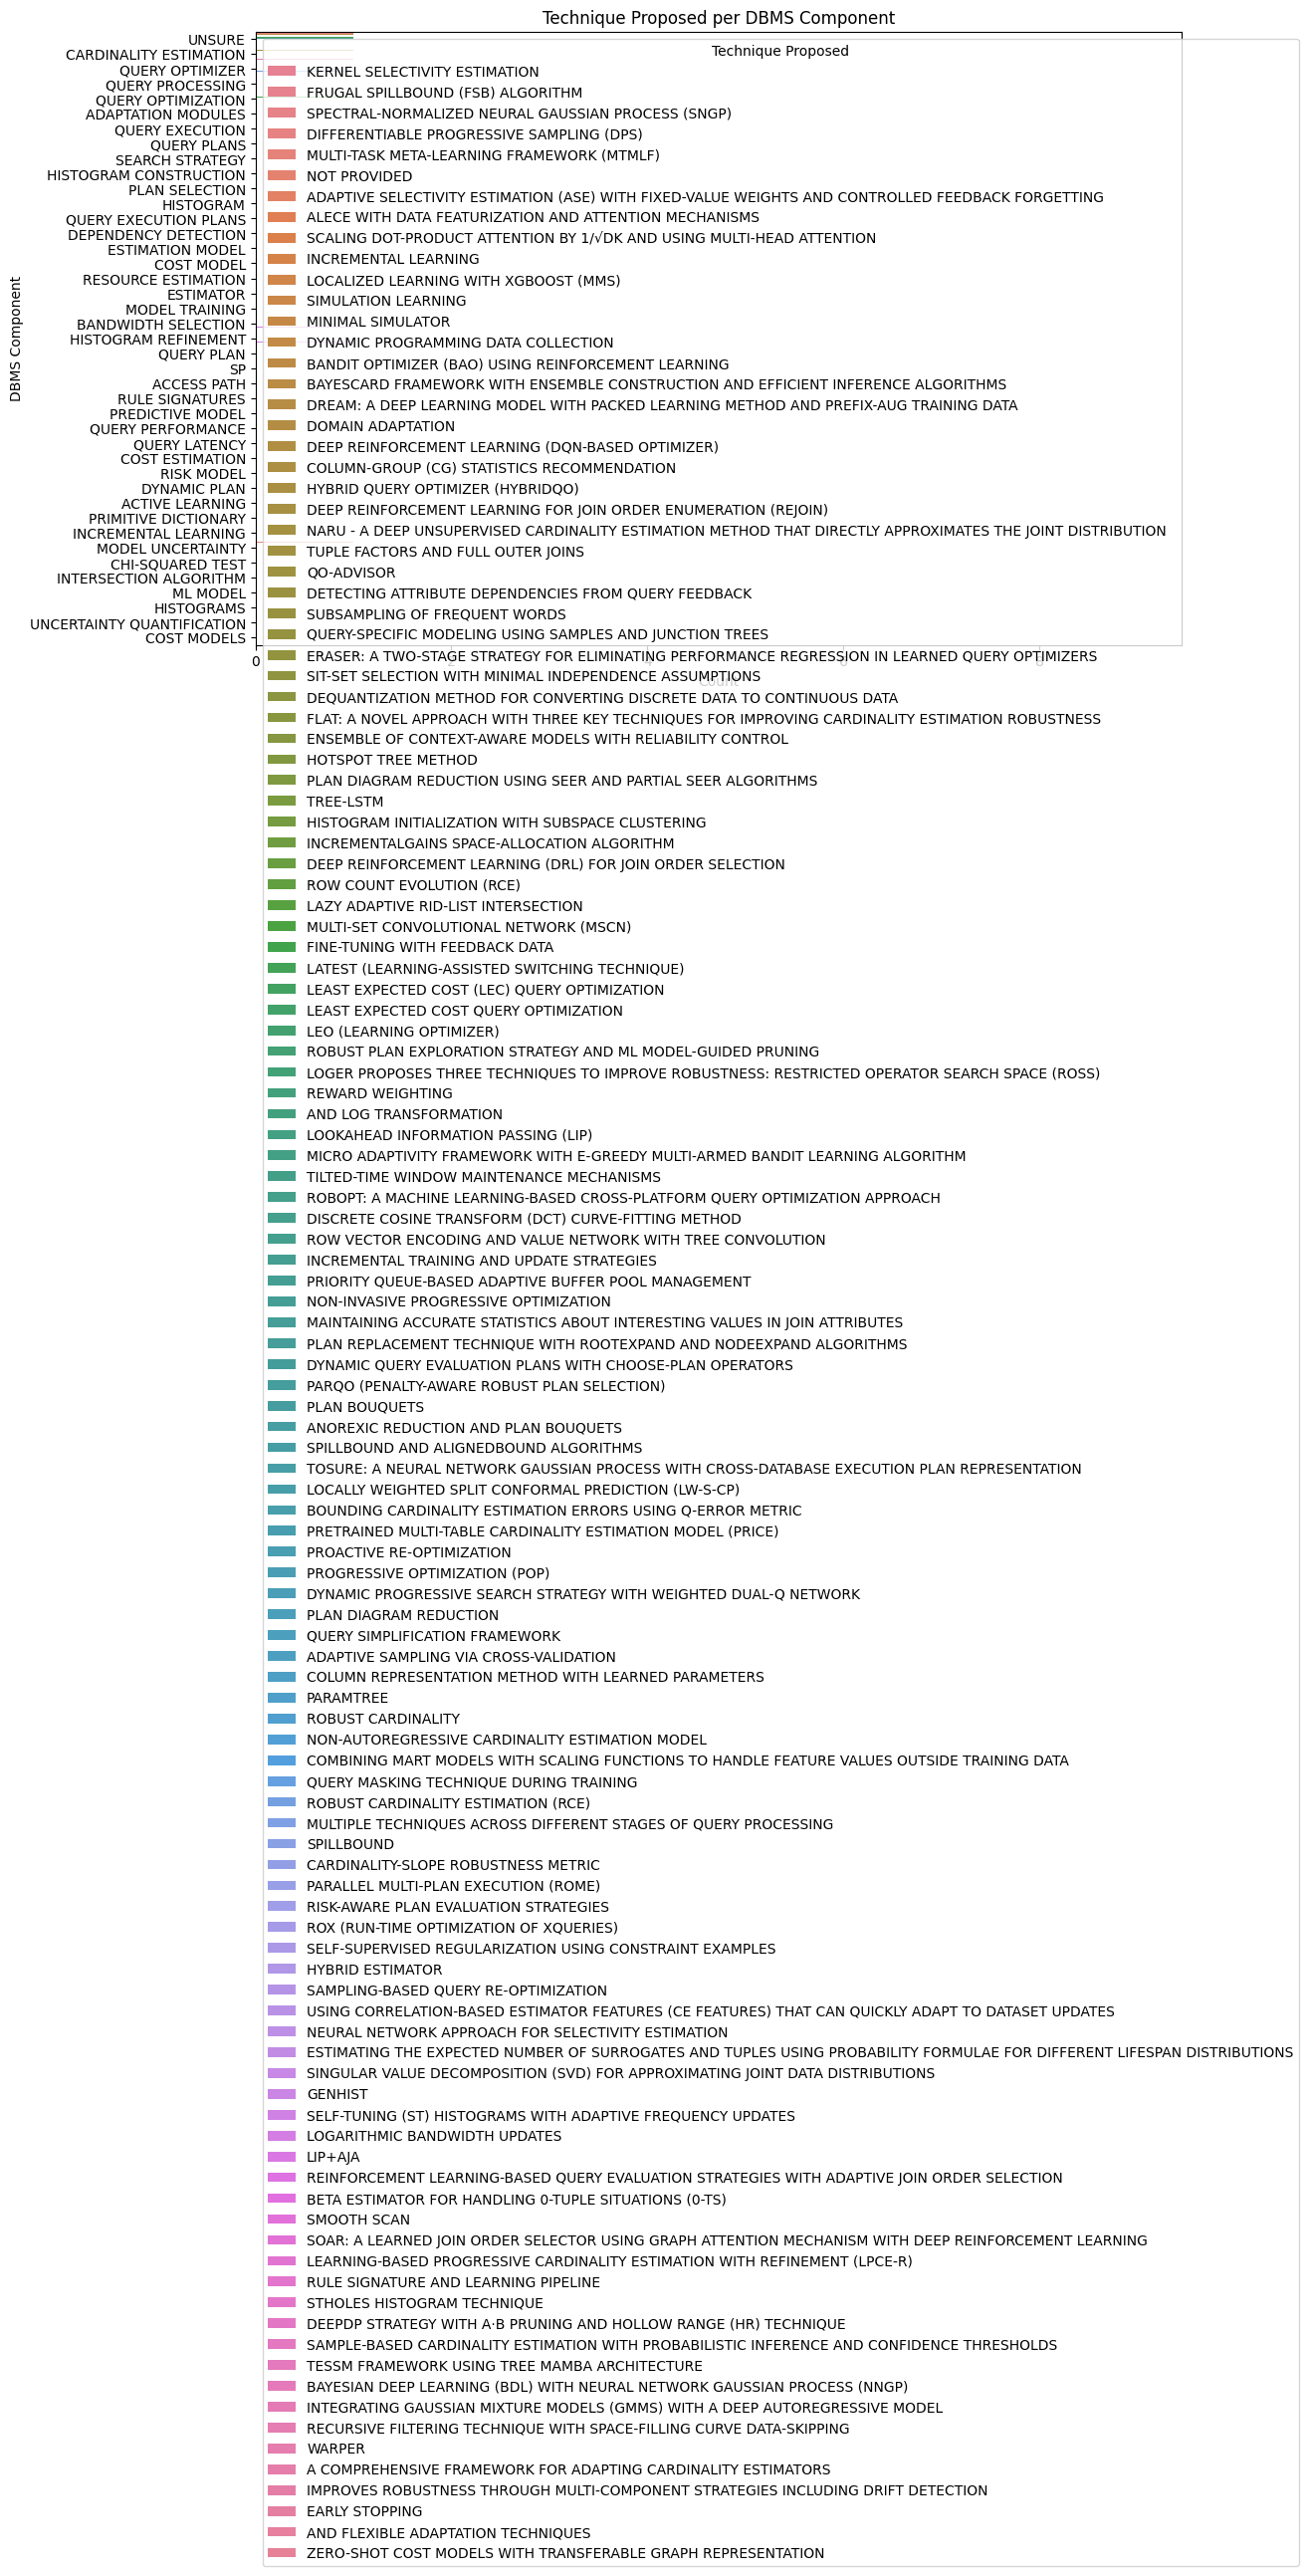

In [162]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Technique Proposed"
)

### DBMS Components Targeted vs Metrics Used

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Glyph 120575 (\N{MATHEMATICAL ITALIC SMALL DELTA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Glyph 119898 (\N{MATHEMATICAL ITALIC SMALL M}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Glyph 120587 (\N{MATHEMATICAL ITALIC SMALL PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/Users/jhaha/Documents/GitHub/FullTextScreener/.env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 120575 (\N{MATHEMATICAL ITALIC SMA

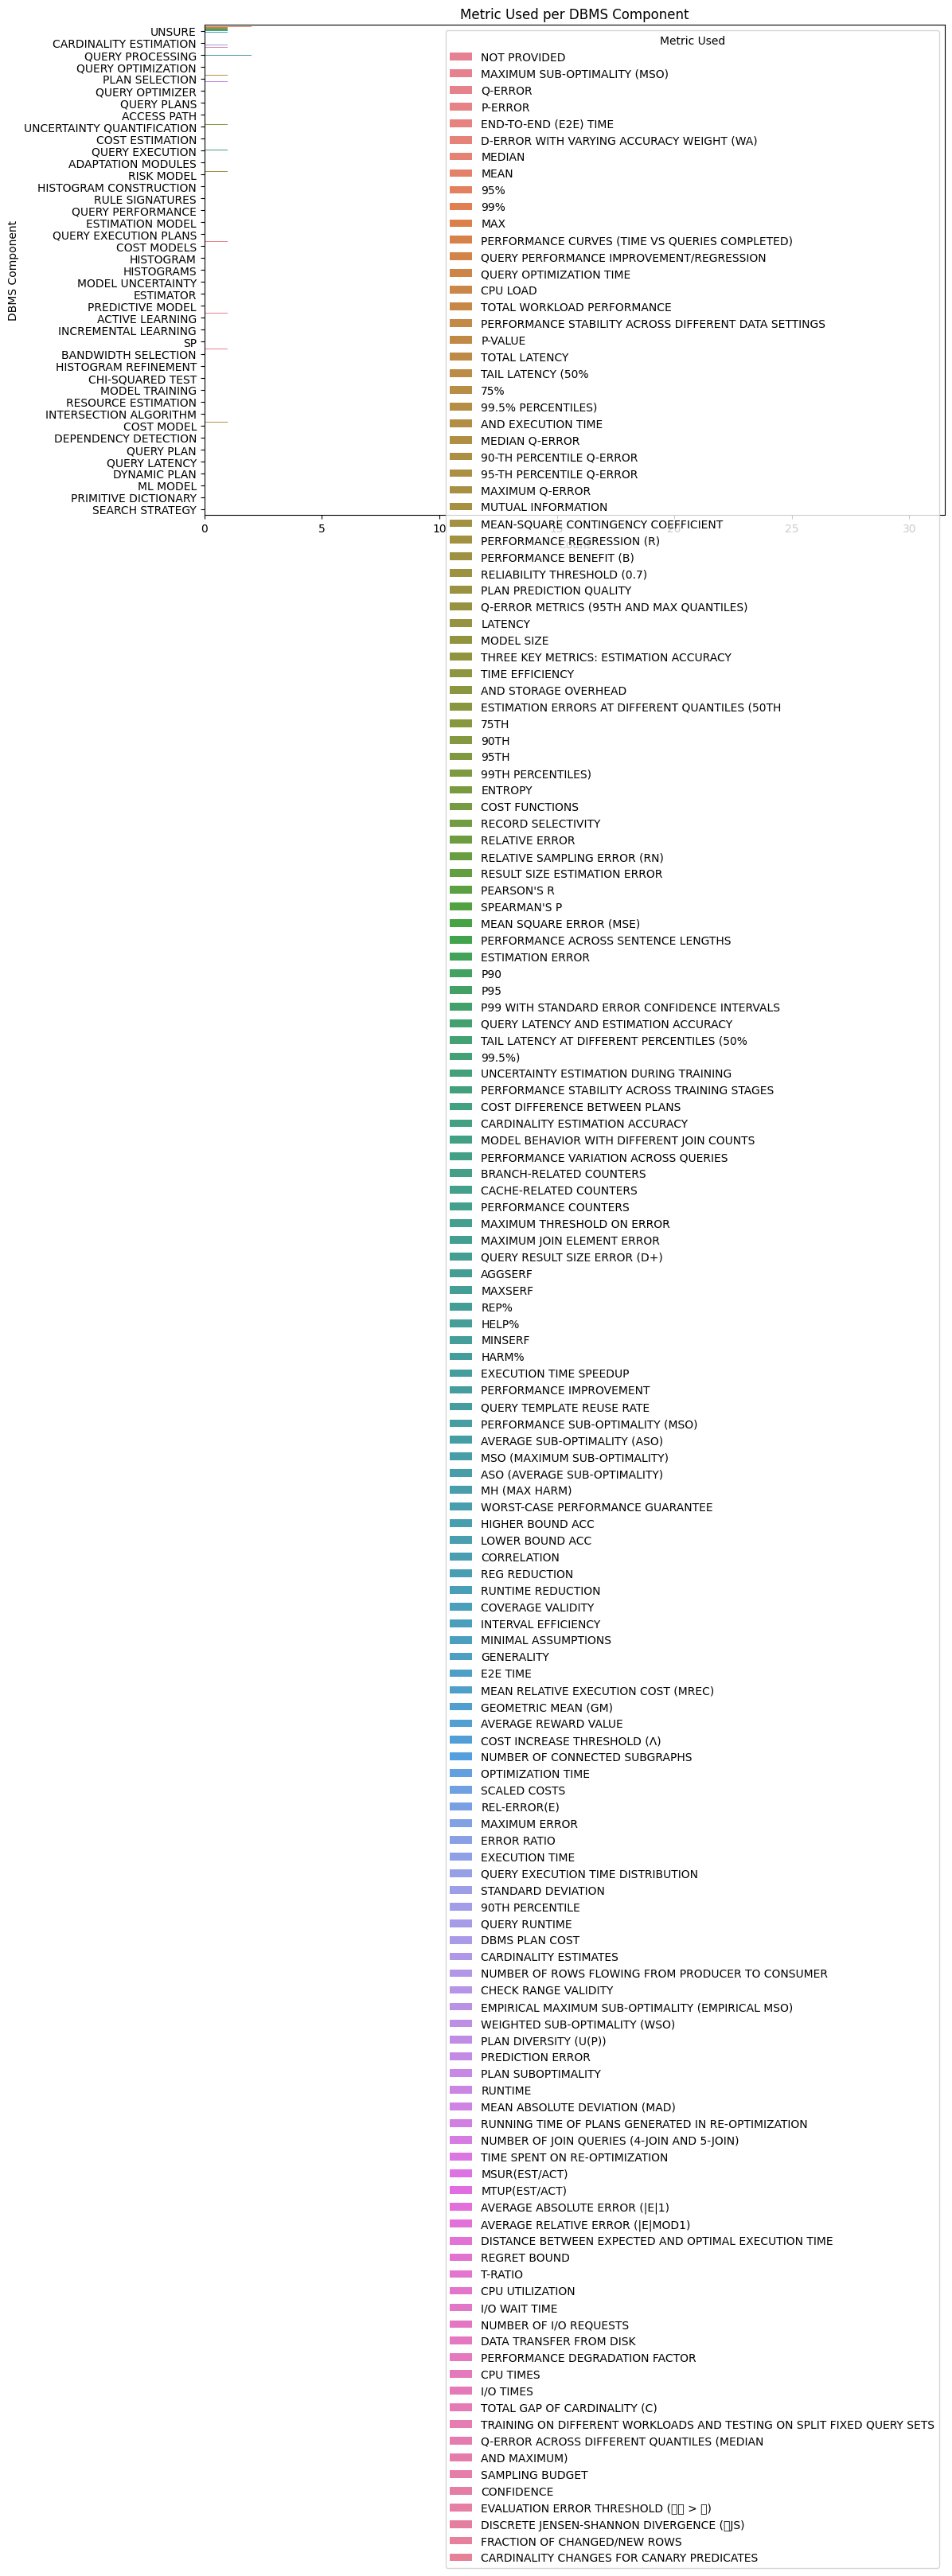

In [163]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Metric Used"
)


### DBMS Components Targeted vs Benchmarks Used

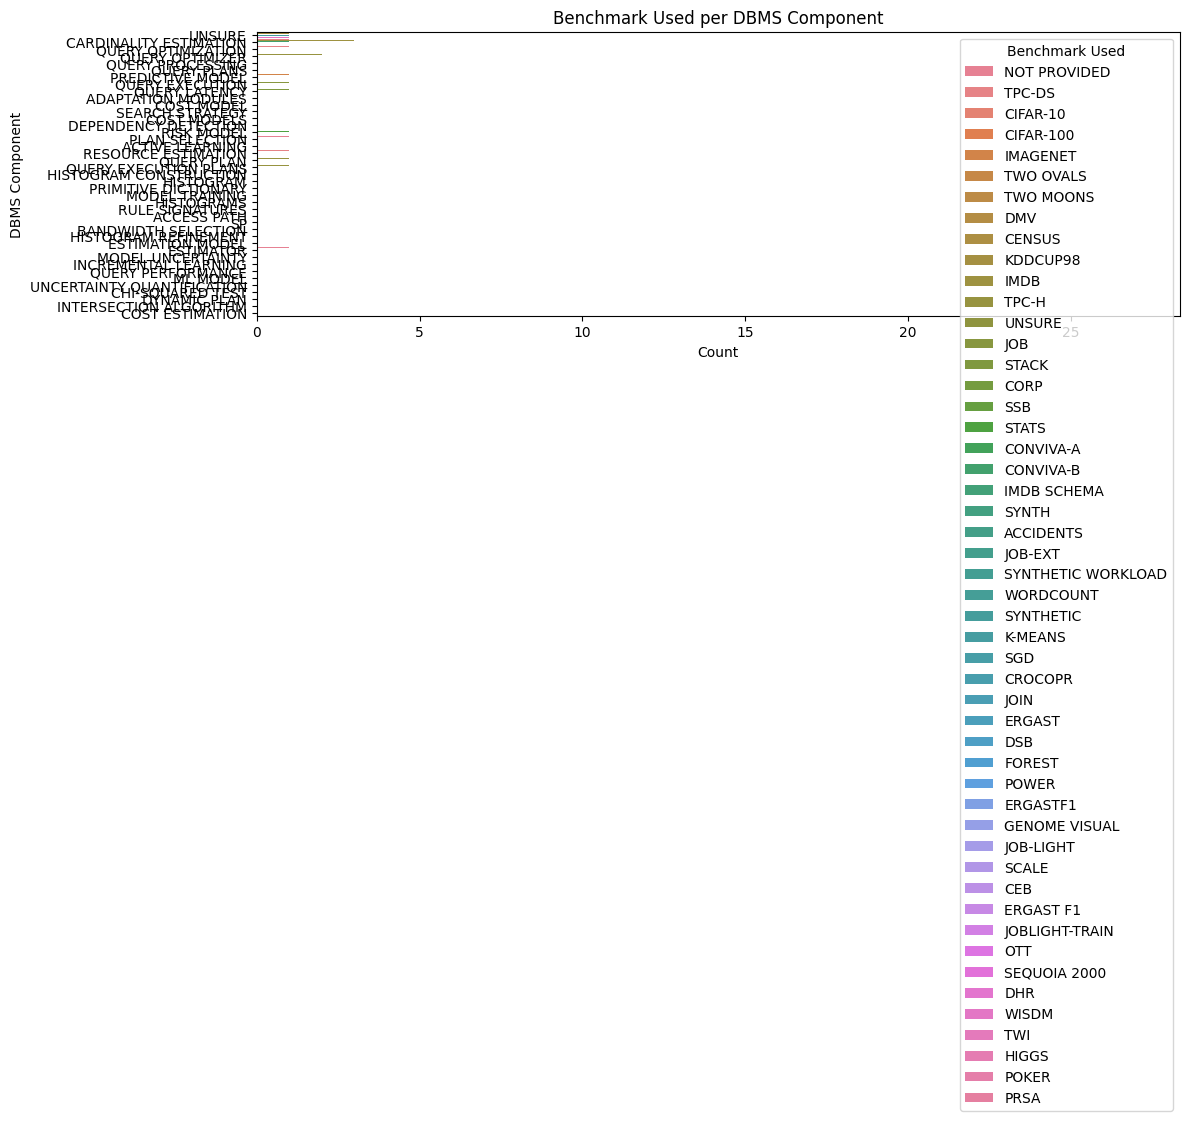

In [164]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Benchmark Used"
)


### DBMS Component Targeted vs Controlled Features

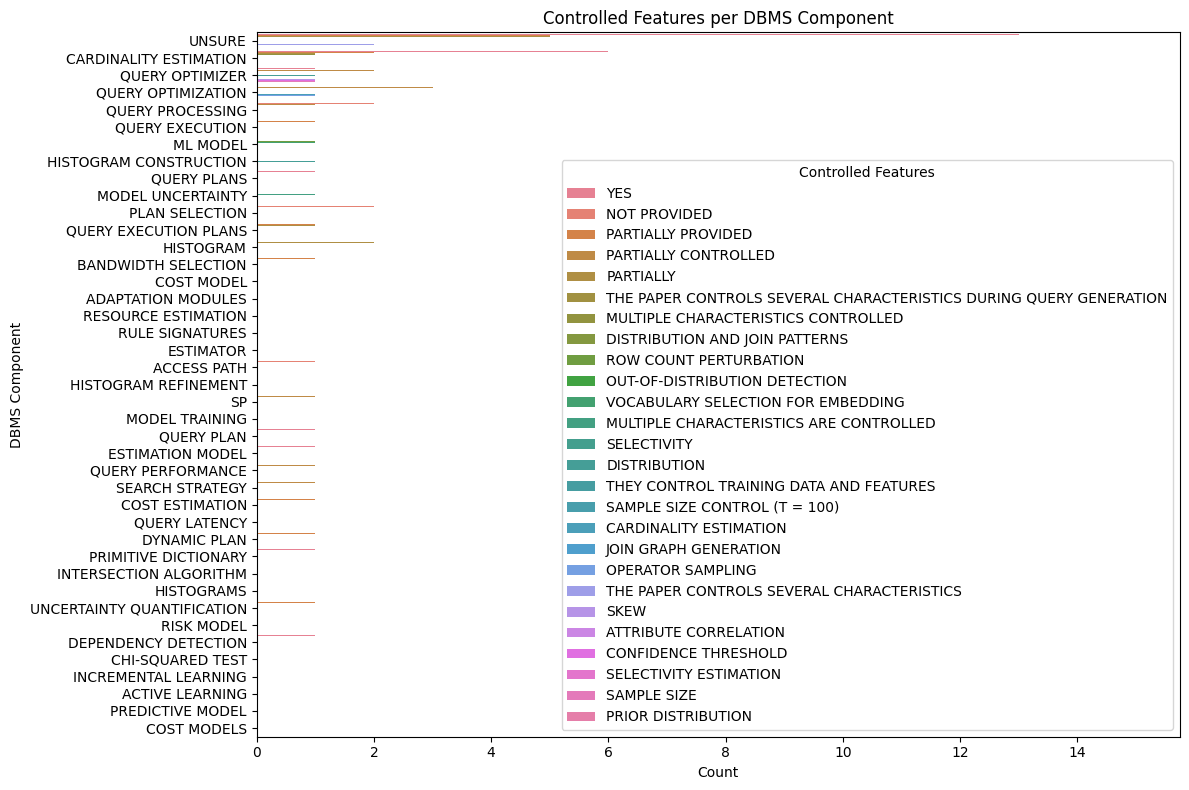

In [165]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Controlled Features"
)


### DBMS Component Targeted per Machine Learning Task Type

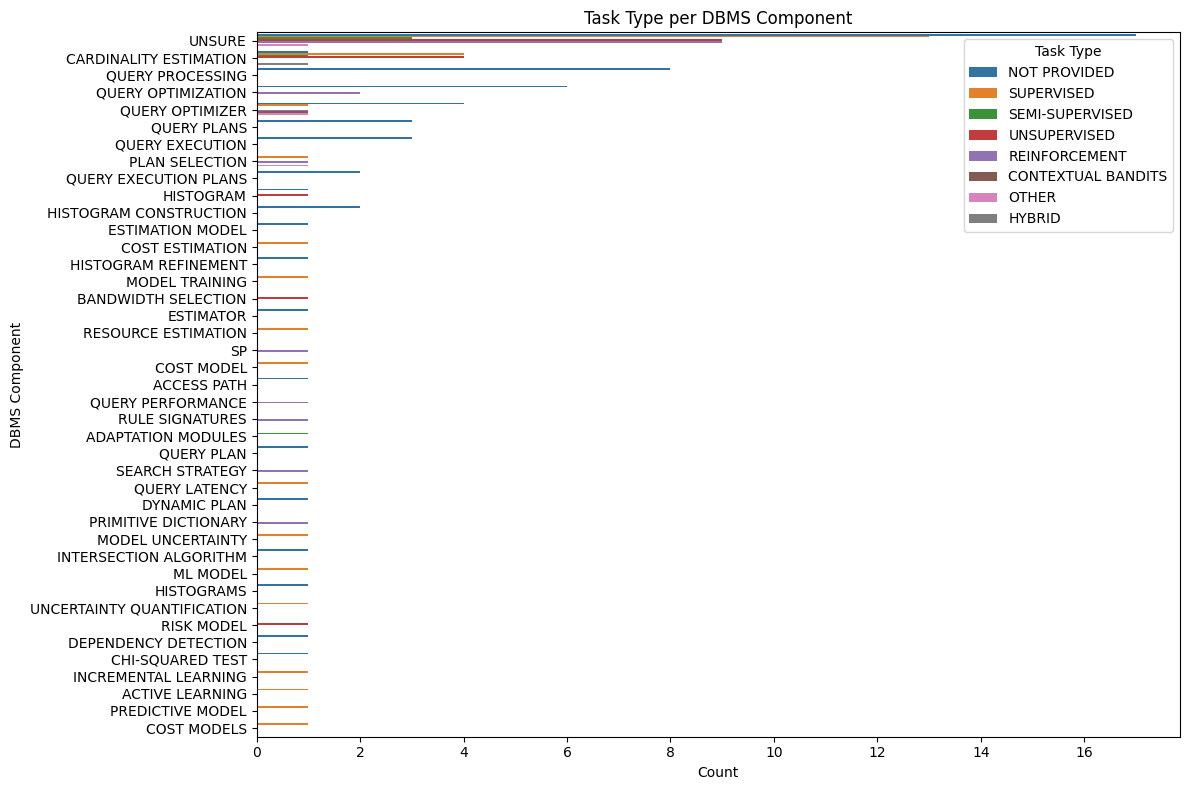

In [166]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Task Type"
)


### Machine Learning Paradigm Used per DBMS Component Targeted

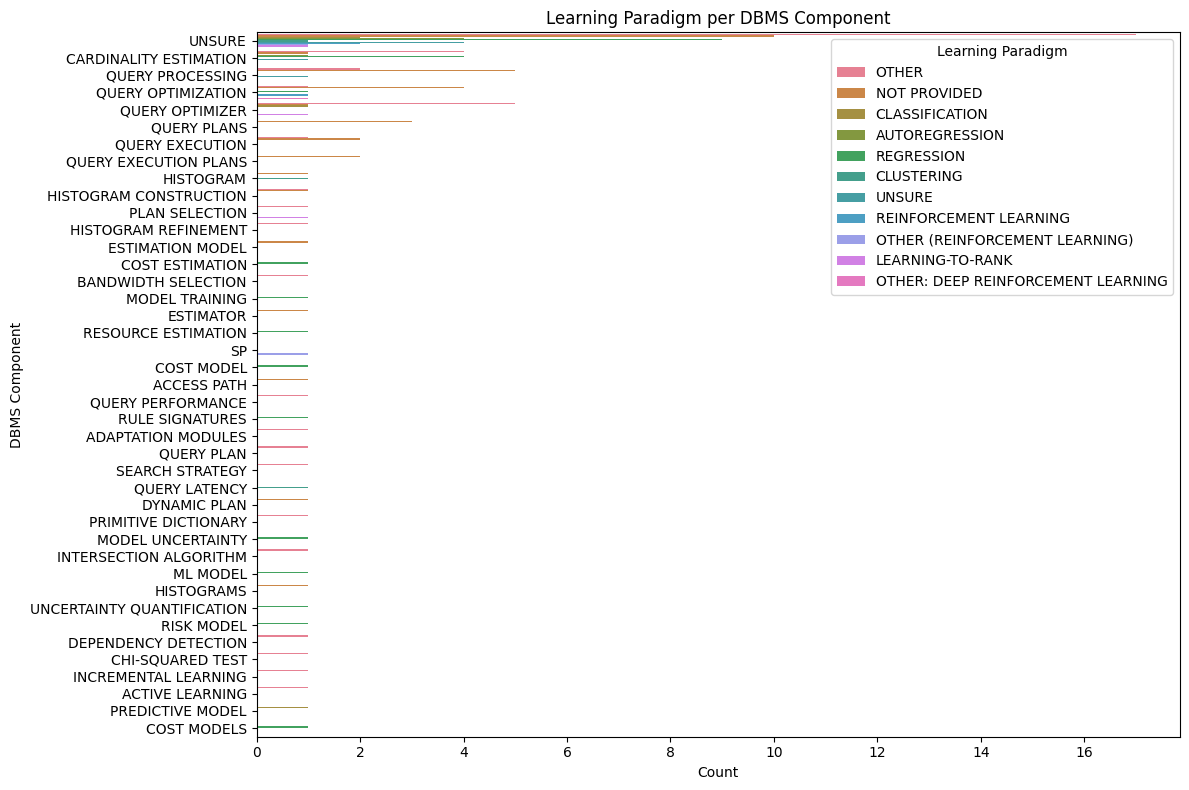

In [167]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Learning Paradigm"
)


### Input Encoding Methods per DBMS Component

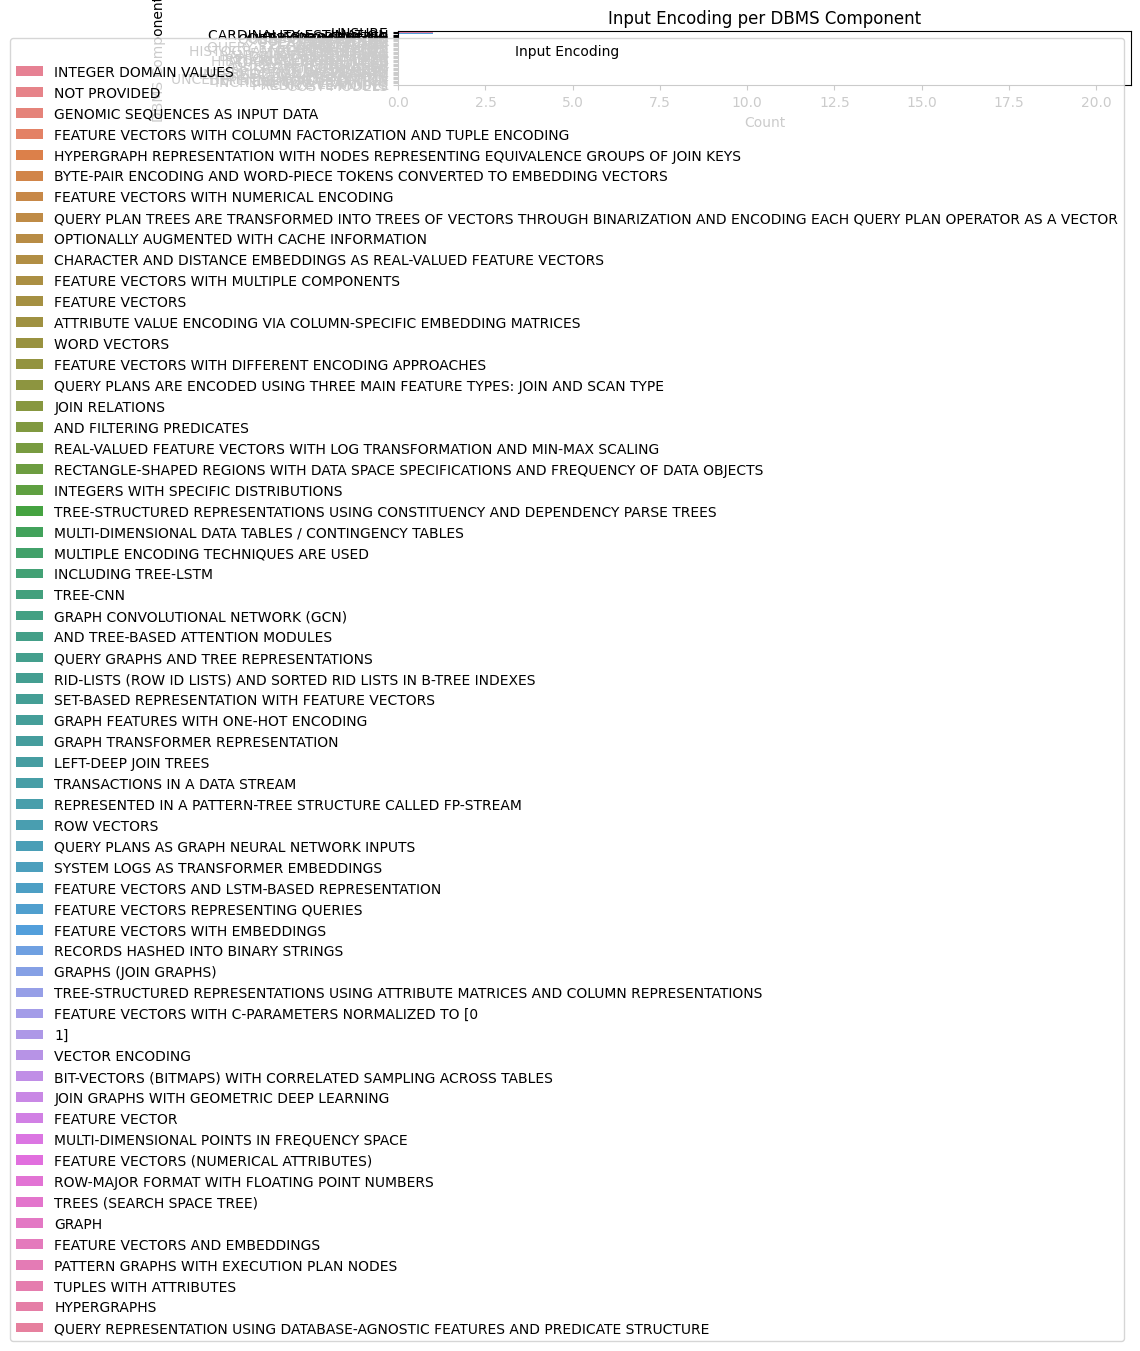

In [168]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Input Encoding"
)


### DBMS Components Targeted vs Uncertainty Evaluation

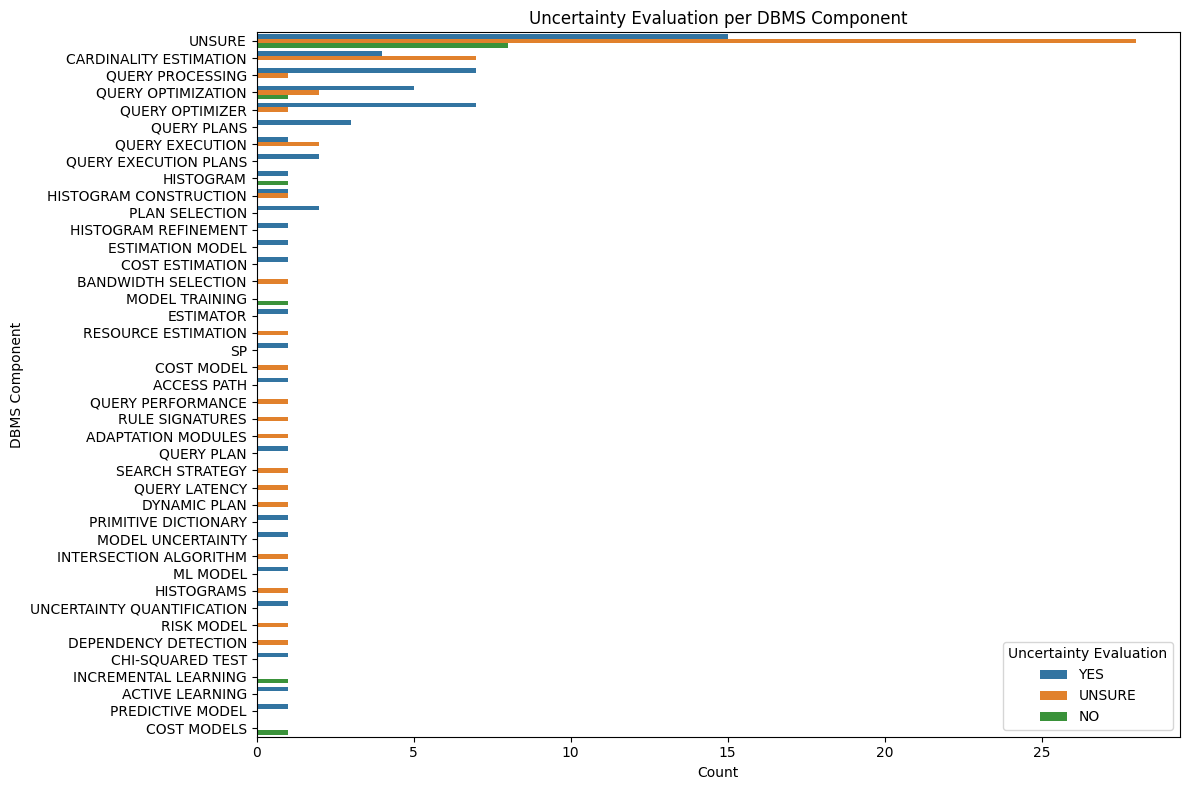

In [169]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Uncertainty Evaluation"
)

### Architecture Used per DBMS Component

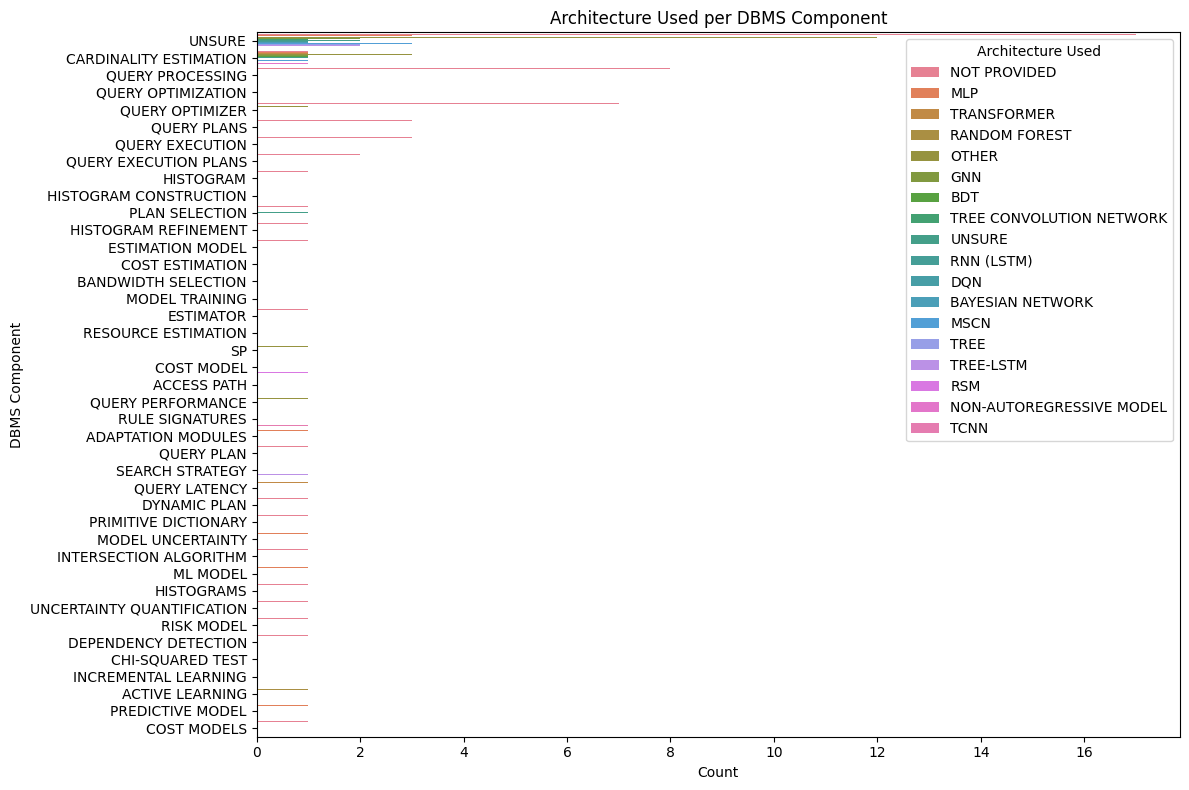

In [170]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="DBMS Component",
    col_y="Architecture Used"
)

## Analysis on the Types of Evaluation

### Types of Evaluation Done Over Time

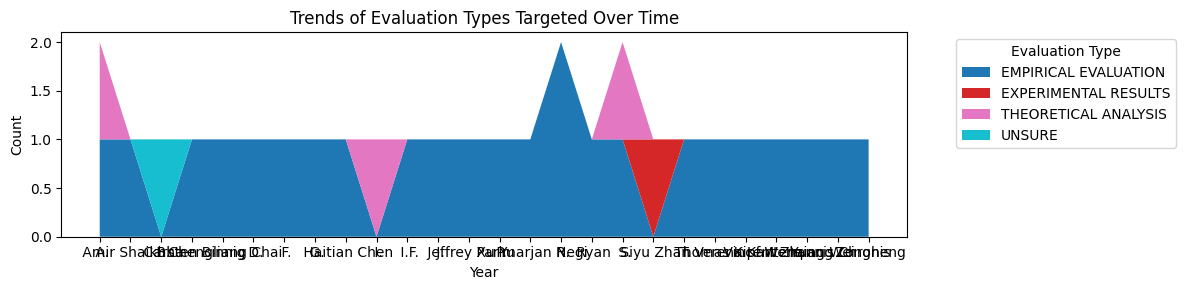

In [171]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Evaluation Type_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Evaluation Type_', '') if x.startswith('Evaluation Type_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Evaluation Types Targeted Over Time")
plt.legend(title="Evaluation Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Evaluation Type

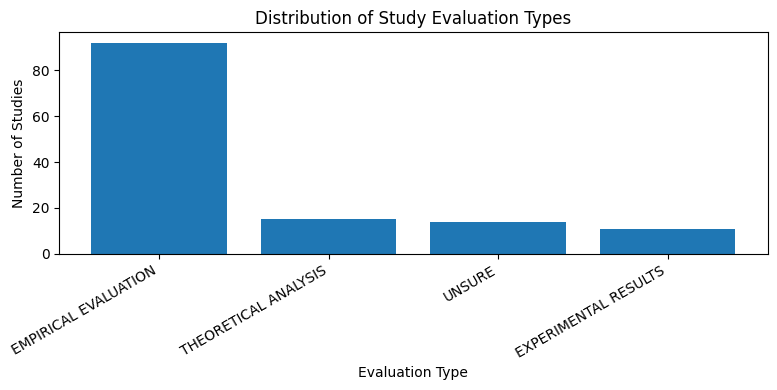

In [172]:
plot_multilabel_distribution(answers_df_encoded, "Evaluation Type", "Distribution of Study Evaluation Types")

## Analysis of Benchmarks Used

### Benchmarks Used Over Time

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/2647101649.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


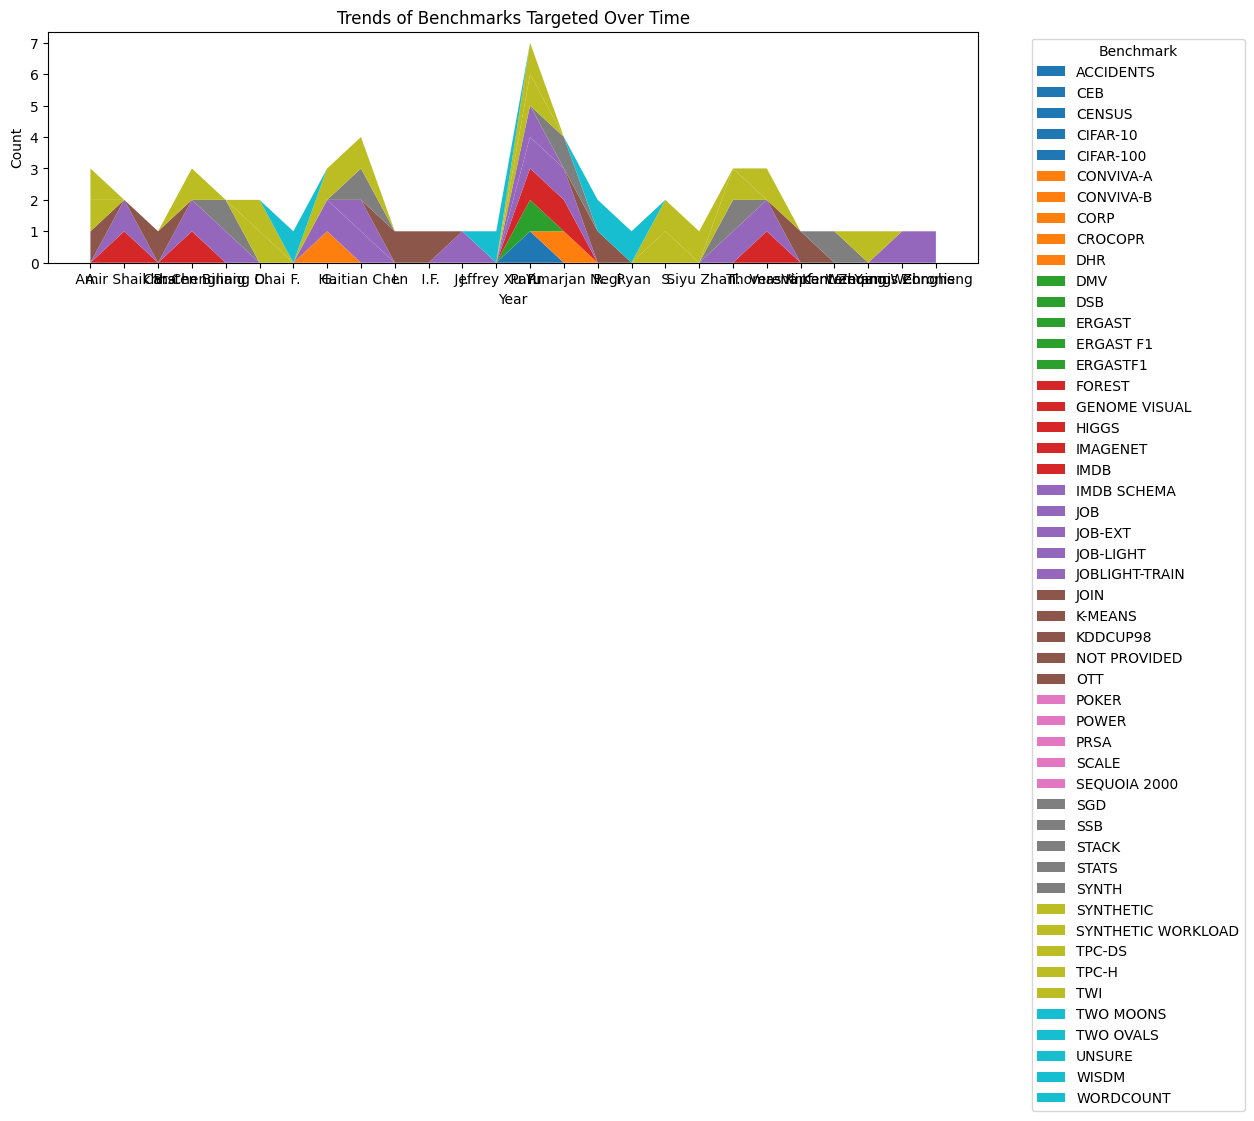

In [173]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Benchmark Used_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Benchmark Used_', '') if x.startswith('Benchmark Used_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Benchmarks Targeted Over Time")
plt.legend(title="Benchmark", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Benchmarks Used

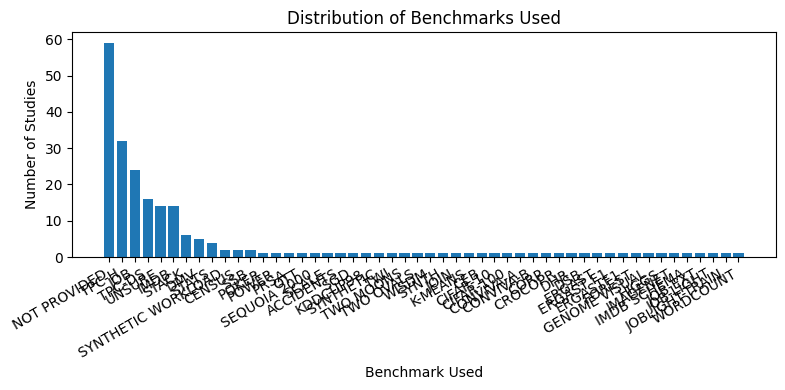

In [174]:
plot_multilabel_distribution(answers_df_encoded, "Benchmark Used", "Distribution of Benchmarks Used")

### Data Source per Benchmark

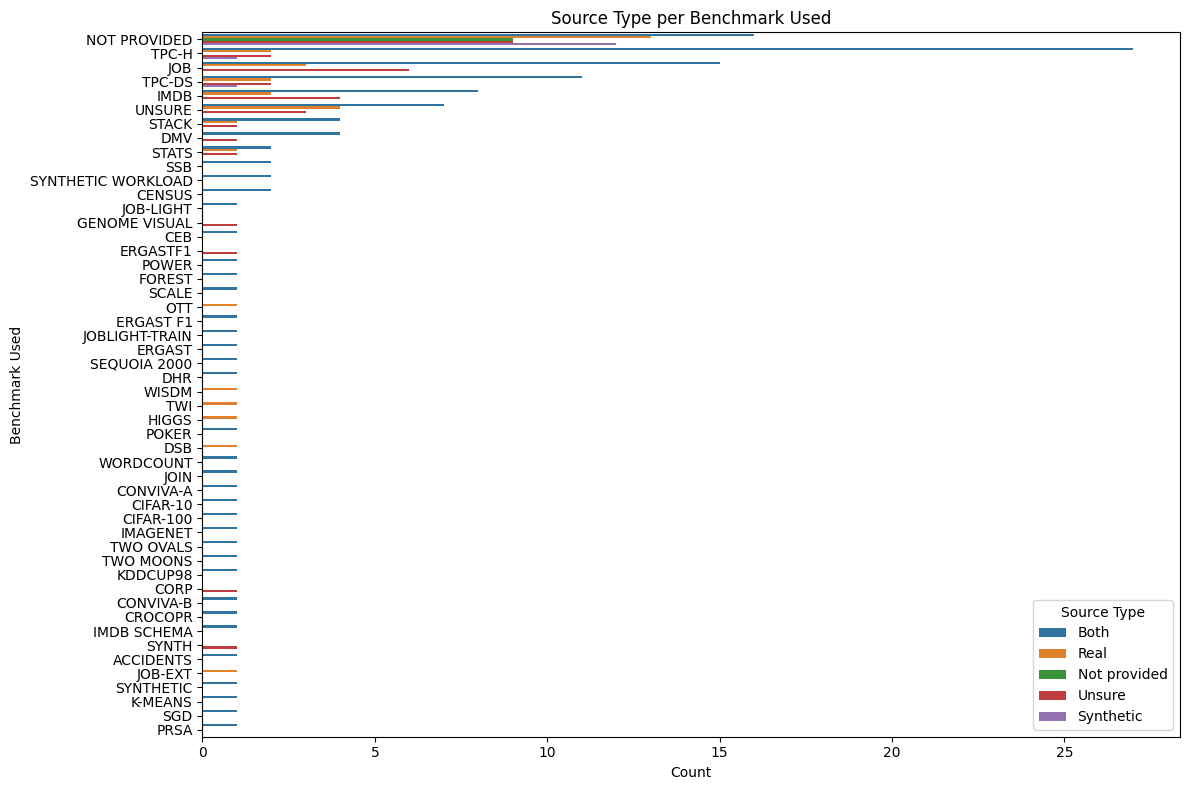

In [175]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Benchmark Used",
    col_y="Source Type"
)

### Machine Learning Task Types per Benchmark

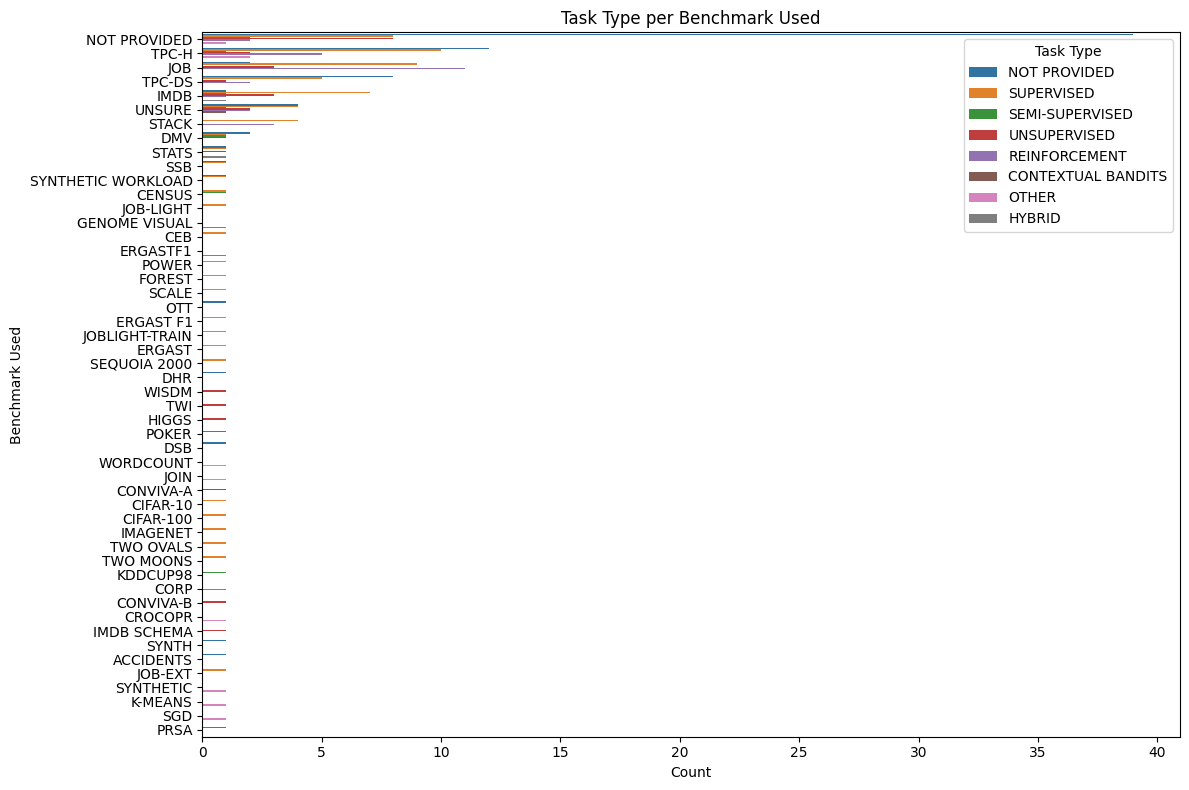

In [176]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Benchmark Used",
    col_y="Task Type"
)

### Machine Learning Paradigms per Benchmark

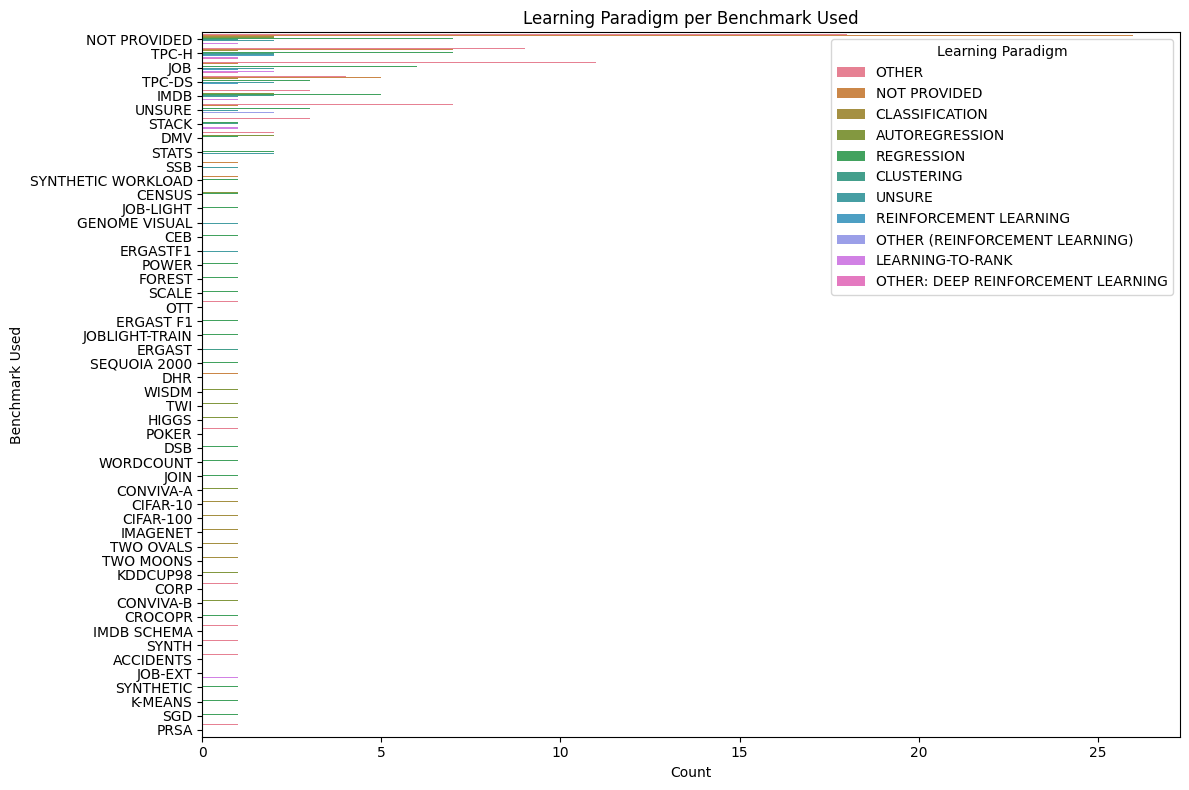

In [177]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Benchmark Used",
    col_y="Learning Paradigm"
)

### Benchmark vs Uncertainty Evaluation

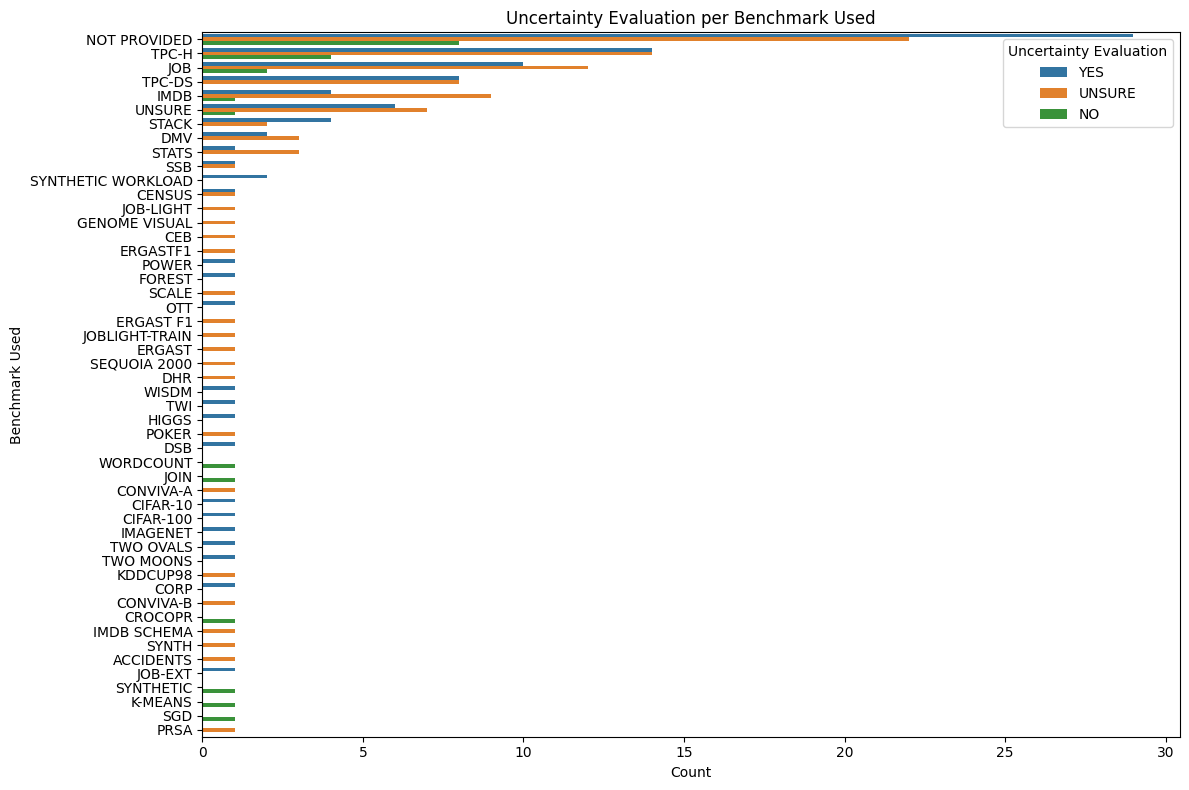

In [178]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Benchmark Used",
    col_y="Uncertainty Evaluation"
)

### Benchmark vs Out of Distribution Evaluation

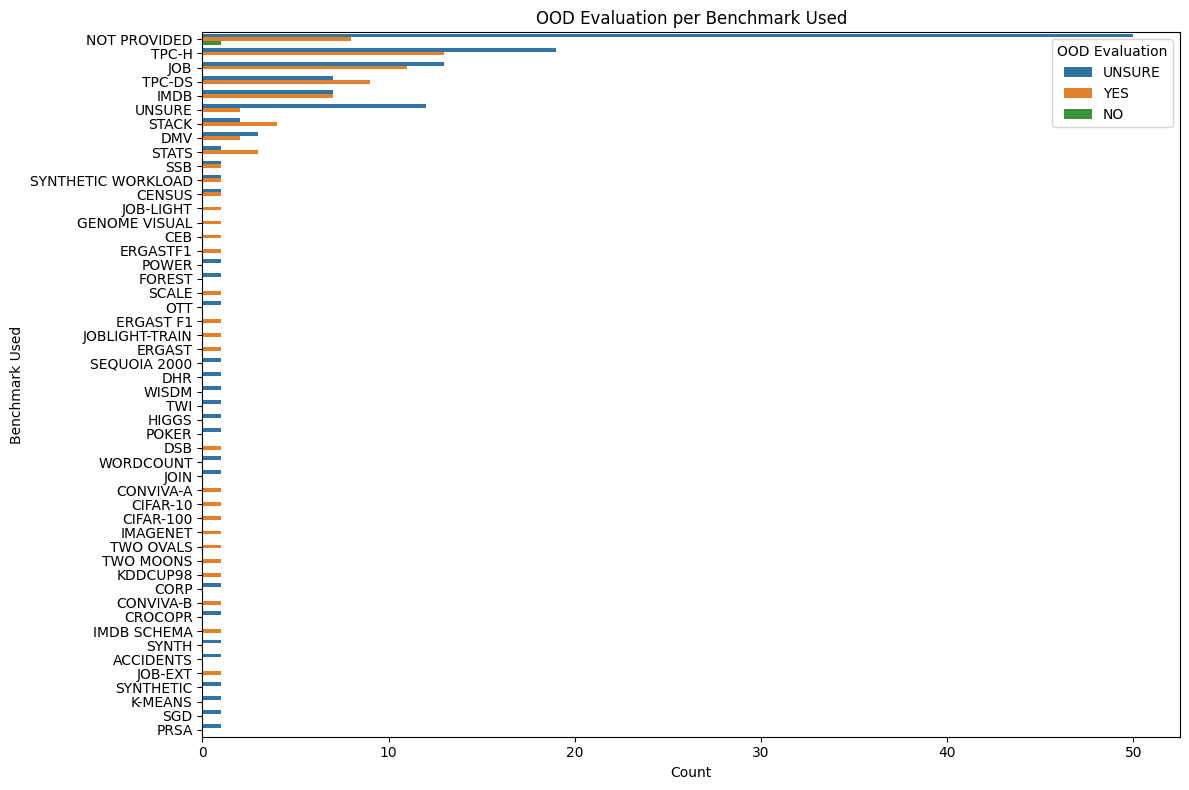

In [179]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Benchmark Used",
    col_y="OOD Evaluation"
)

## Analysis on Controlled Features

### Controlled Features During Training Over Time

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/2594641673.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


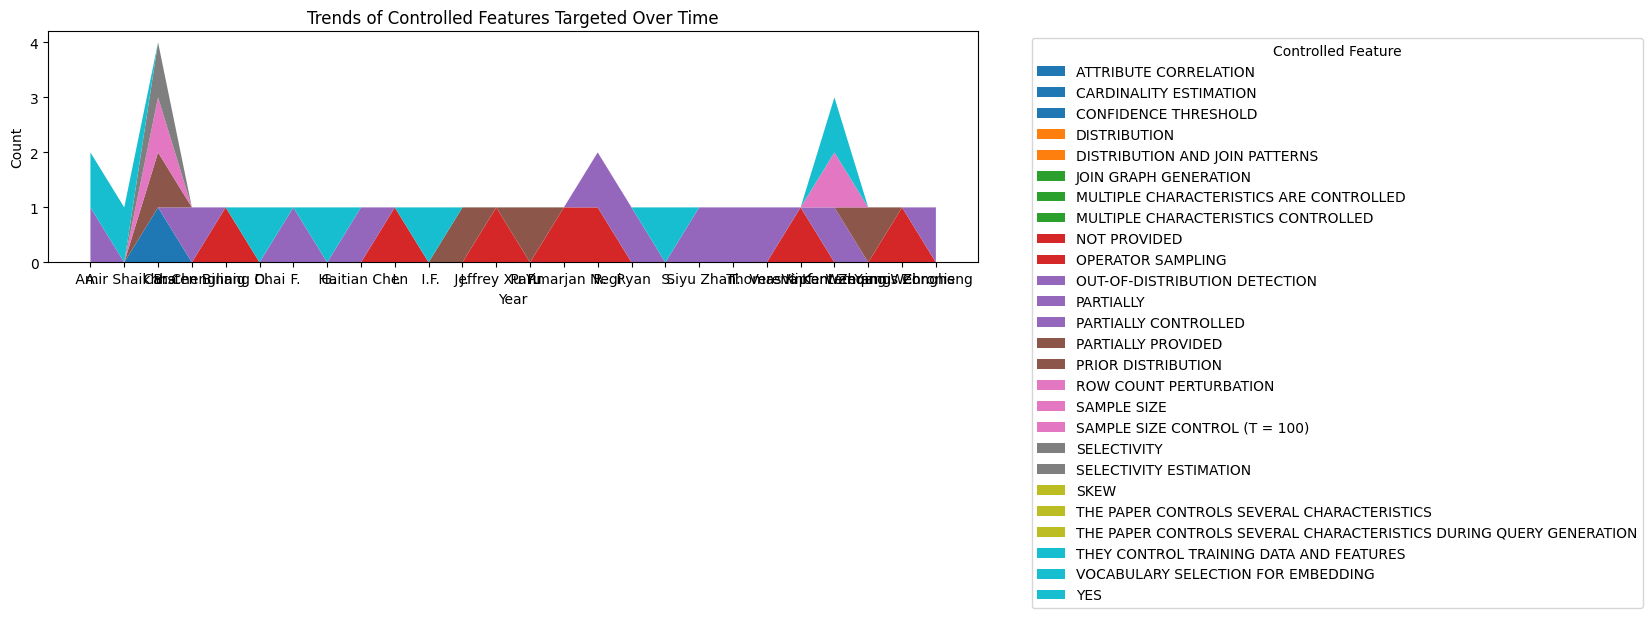

In [180]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Controlled Features_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Controlled Features_', '') if x.startswith('Controlled Features_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Controlled Features Targeted Over Time")
plt.legend(title="Controlled Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Features Controlled During Training

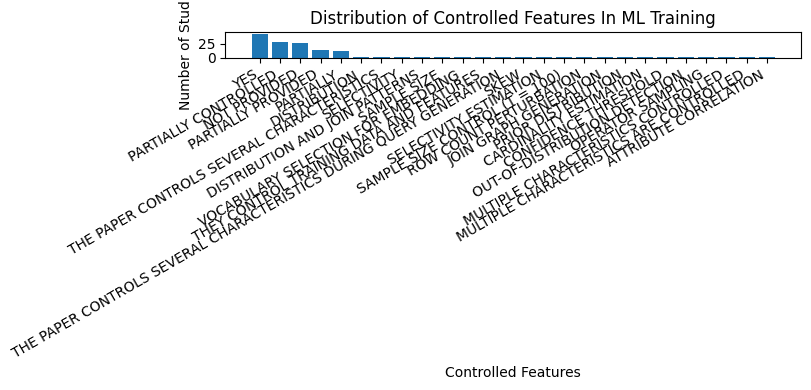

In [181]:
plot_multilabel_distribution(answers_df_encoded, "Controlled Features", "Distribution of Controlled Features In ML Training")

### Features Controlled During Training Per ML Task Type

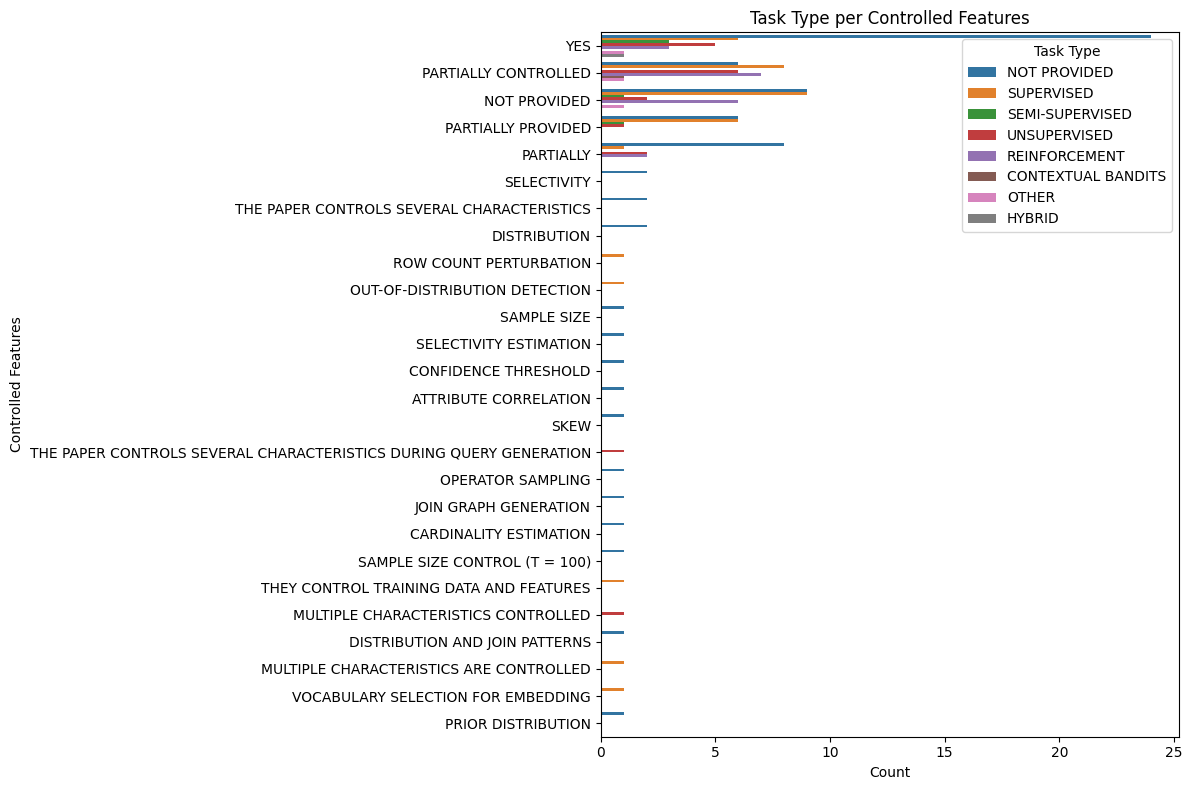

In [182]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Controlled Features",
    col_y="Task Type"
)

### Features Controlled During Training Per ML Task Type

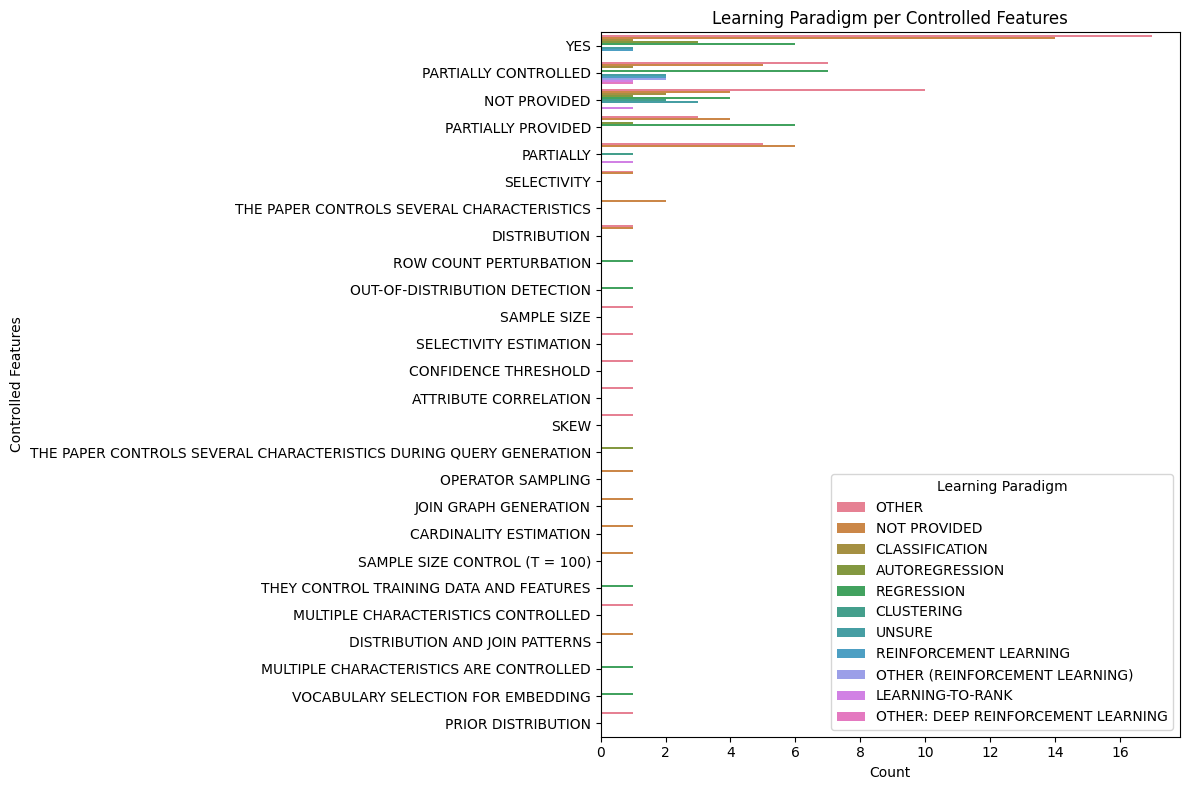

In [183]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Controlled Features",
    col_y="Learning Paradigm"
)

### Features Controlled per Model Architecture

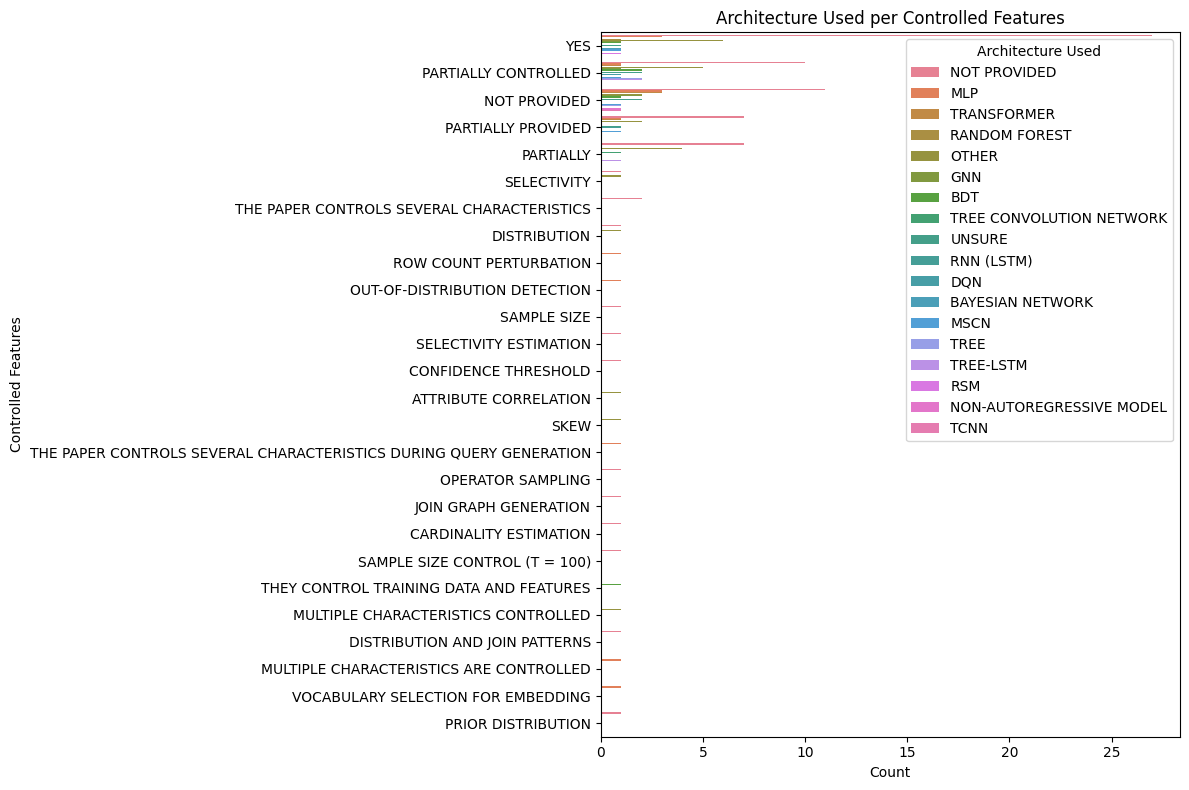

In [184]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Controlled Features",
    col_y="Architecture Used"
)

## Analysis on Machine Learning Task Type

### Distribution of Task Type Over all Papers Over Time

In [ ]:
stack_data.shape

[array([[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]),
 array([[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        

ValueError: 'y2' is not 1-dimensional

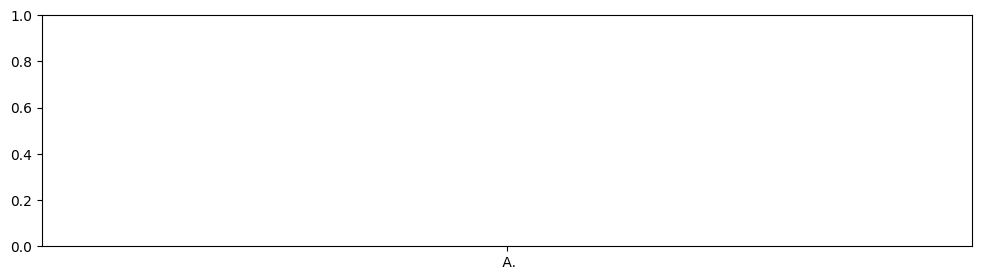

In [185]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Task Type_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Task Type_', '') if x.startswith('Task Type_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Task Types Targeted Over Time")
plt.legend(title="Task Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Distribution of Task Type Over all Papers

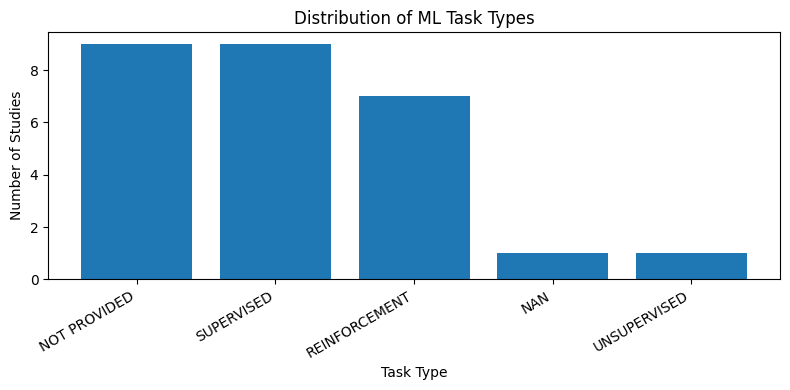

In [ ]:
plot_multilabel_distribution(answers_df_encoded, "Task Type", "Distribution of ML Task Types")

### Comparing distribution of Learning Pardigm per Task Type

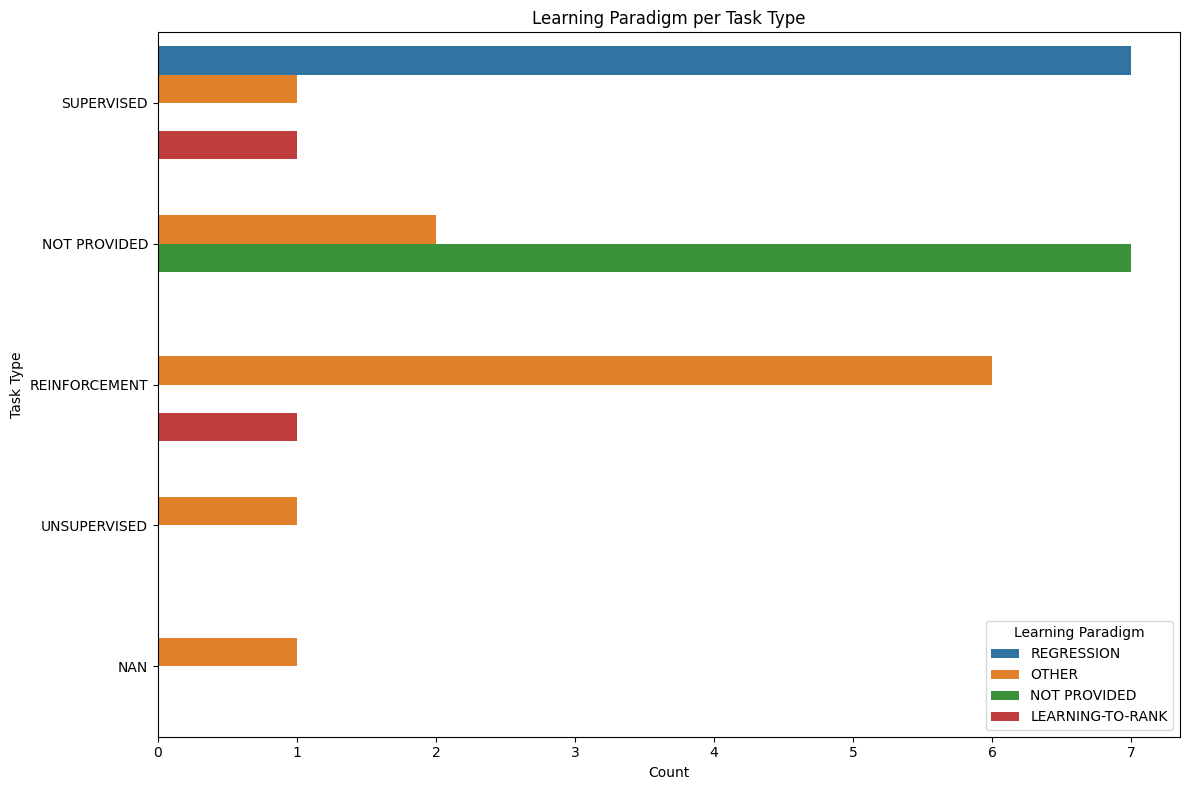

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Task Type",
    col_y="Learning Paradigm"
)

### Data Generation methods per Task Type

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/Users/jhaha/Documents/GitHub/FullTextScreener/.env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


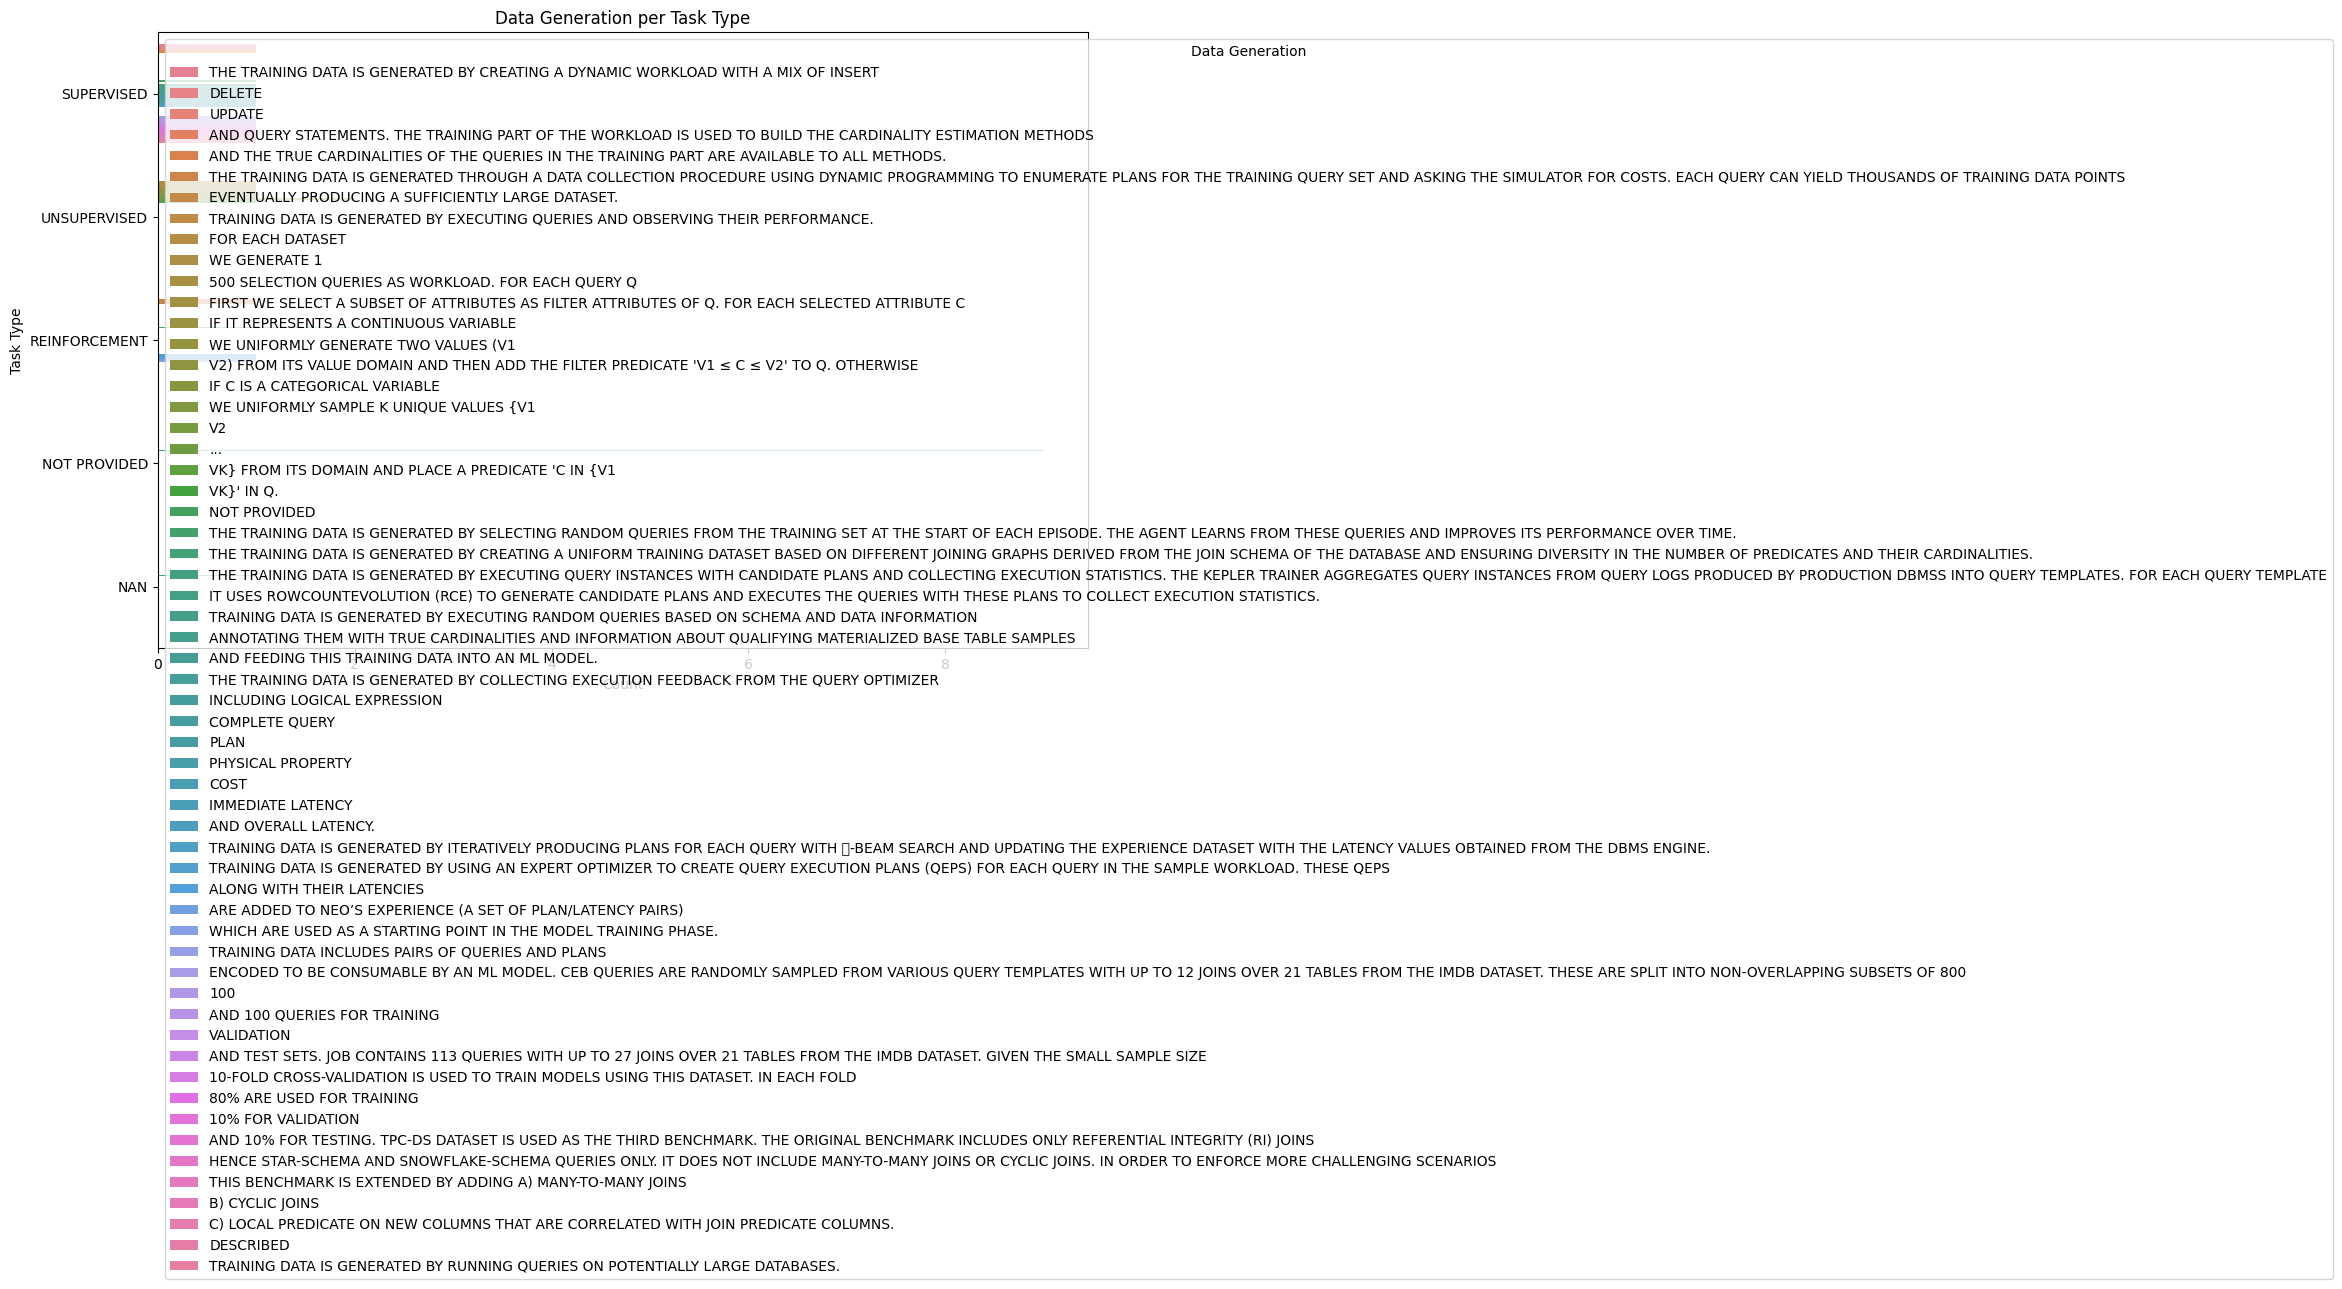

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Task Type",
    col_y="Data Generation"
)

### Distribution of Encoding Techniques per Task Type

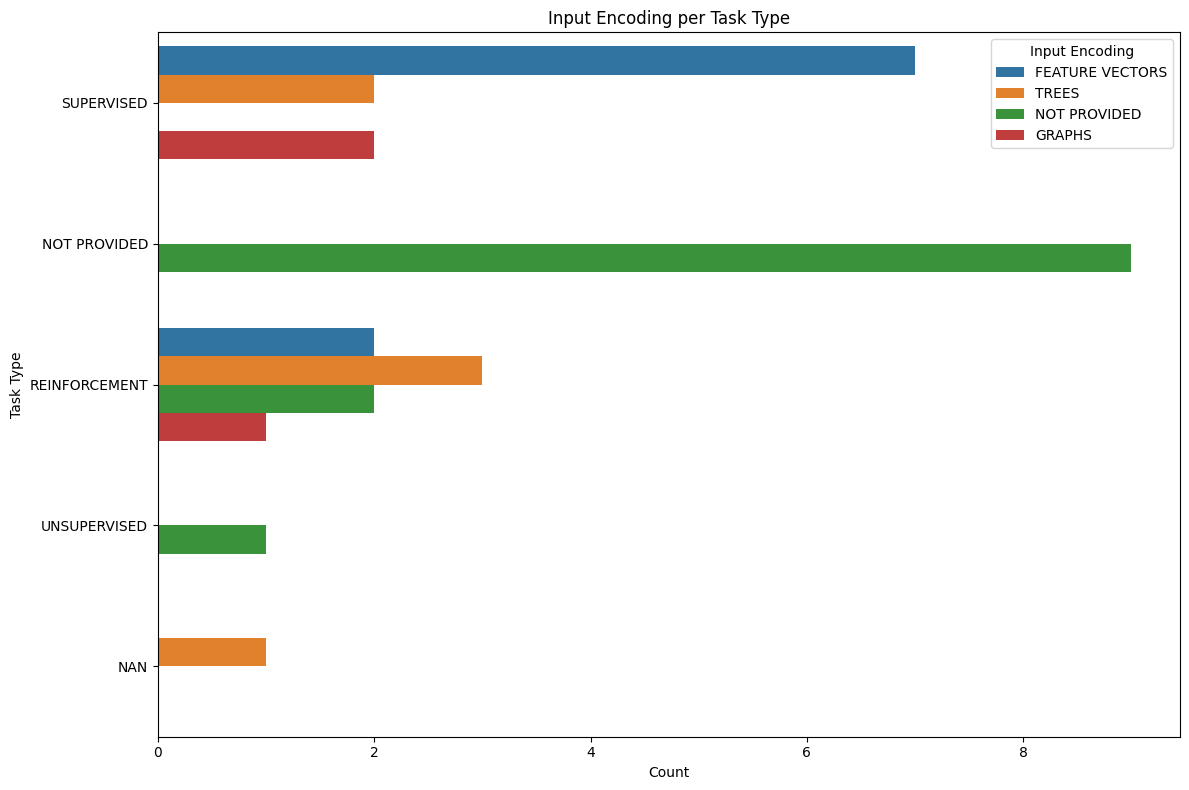

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Task Type",
    col_y="Input Encoding"
)

###  Uncertainty Evaluation Counts per Task Type

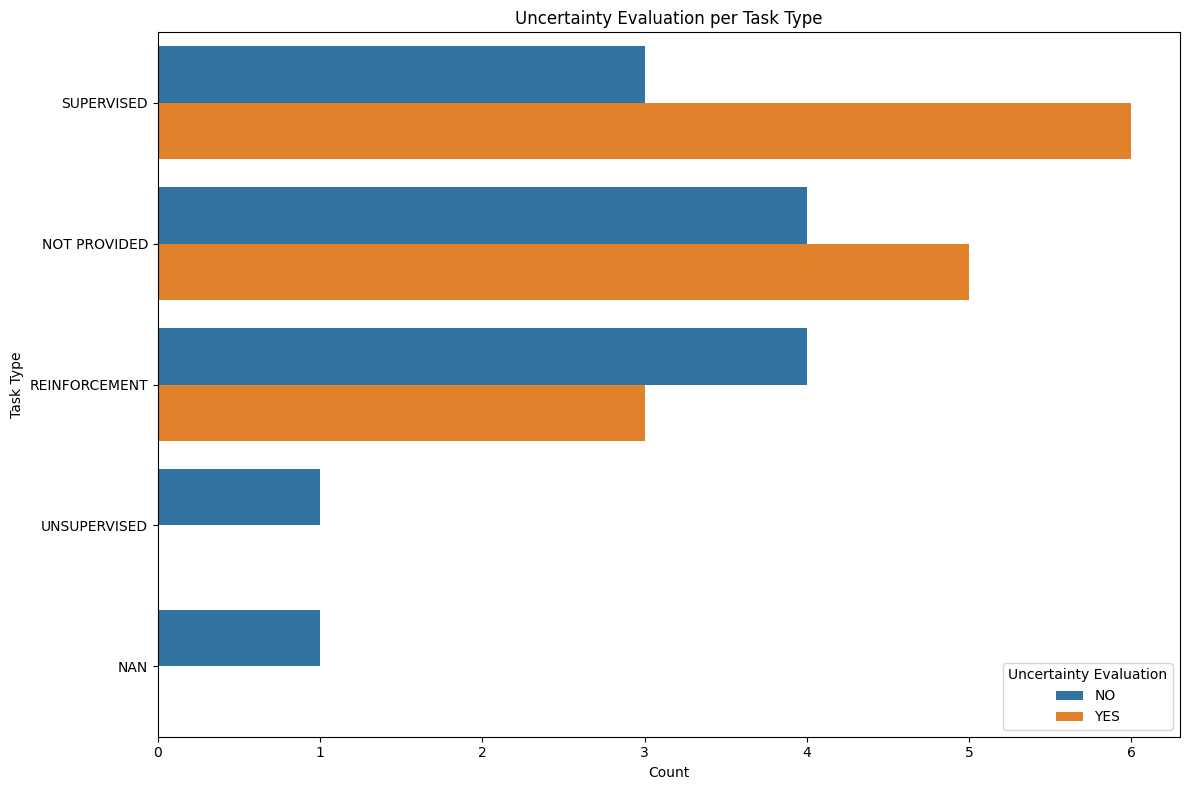

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Task Type",
    col_y="Uncertainty Evaluation"
)

### Distribution of Techniques that Evaluate Out of Distribution per Task Type

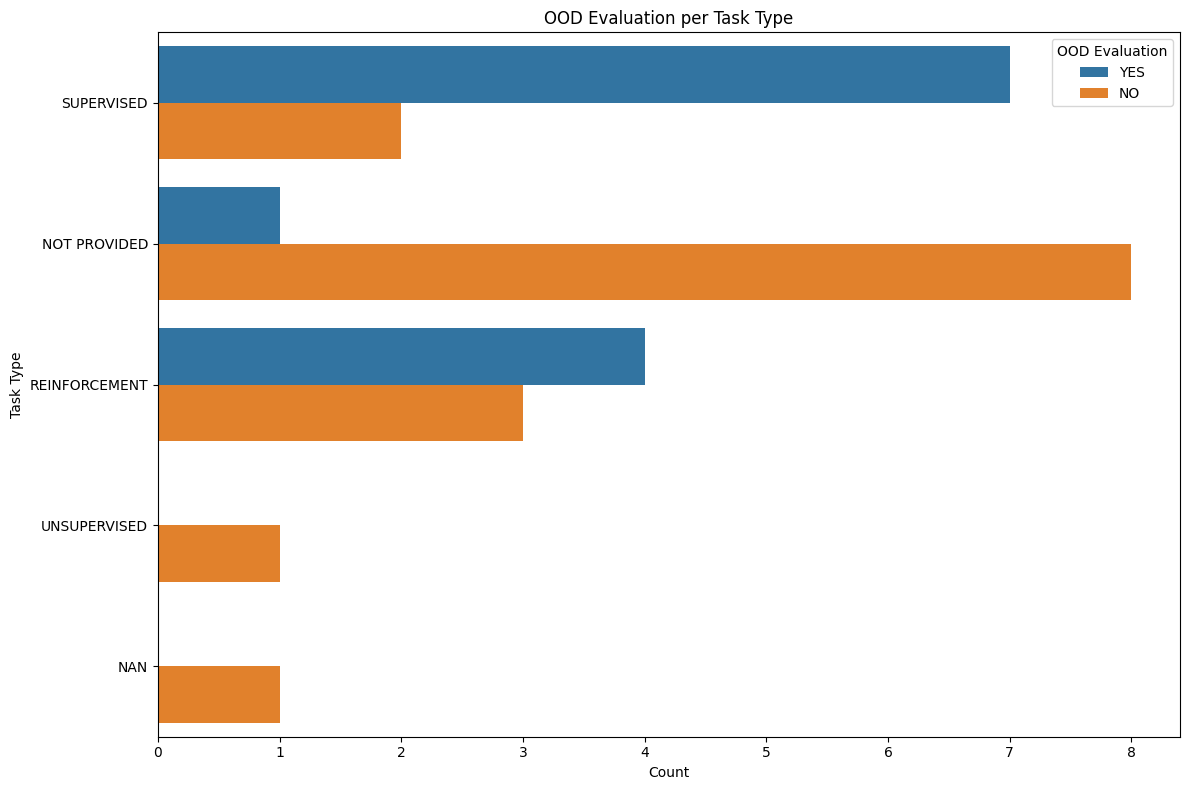

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Task Type",
    col_y="OOD Evaluation"
)

### Distribution of Architecture per Task Type

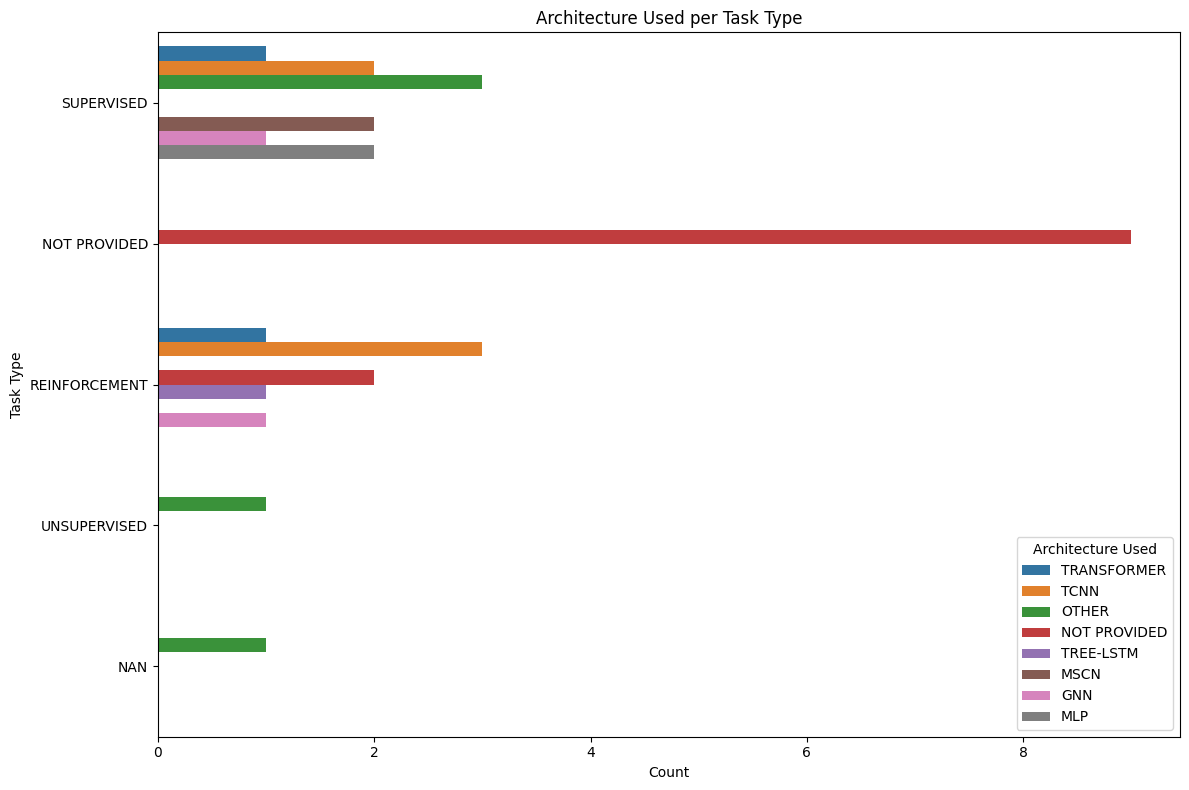

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Task Type",
    col_y="Architecture Used"
)

## Analysis on Learning Paradigm

### Distribution of Learning Paradigm Over Time

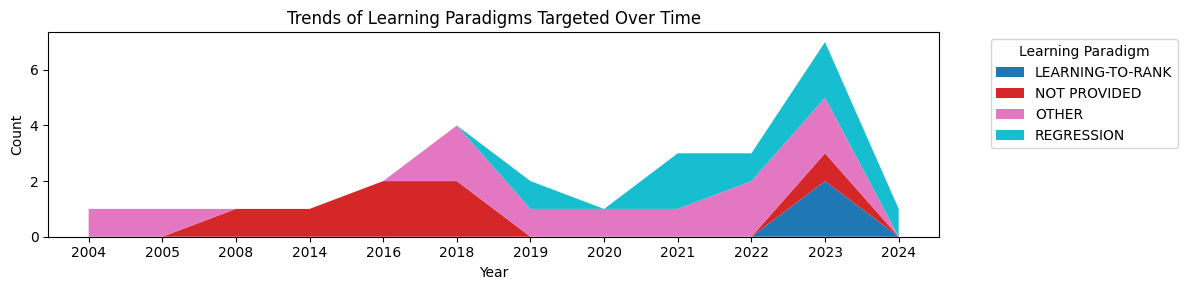

In [ ]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Learning Paradigm_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Learning Paradigm_', '') if x.startswith('Learning Paradigm_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Learning Paradigms Targeted Over Time")
plt.legend(title="Learning Paradigm", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Distribution of Learning Paradigm Over all Papers

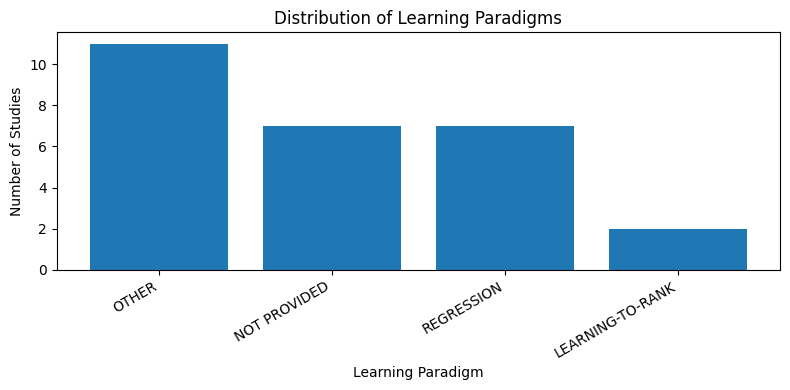

In [ ]:
plot_multilabel_distribution(answers_df_encoded, "Learning Paradigm", "Distribution of Learning Paradigms")

### All Data Generation Methods per Machine Learning Paradigm

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/Users/jhaha/Documents/GitHub/FullTextScreener/.env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


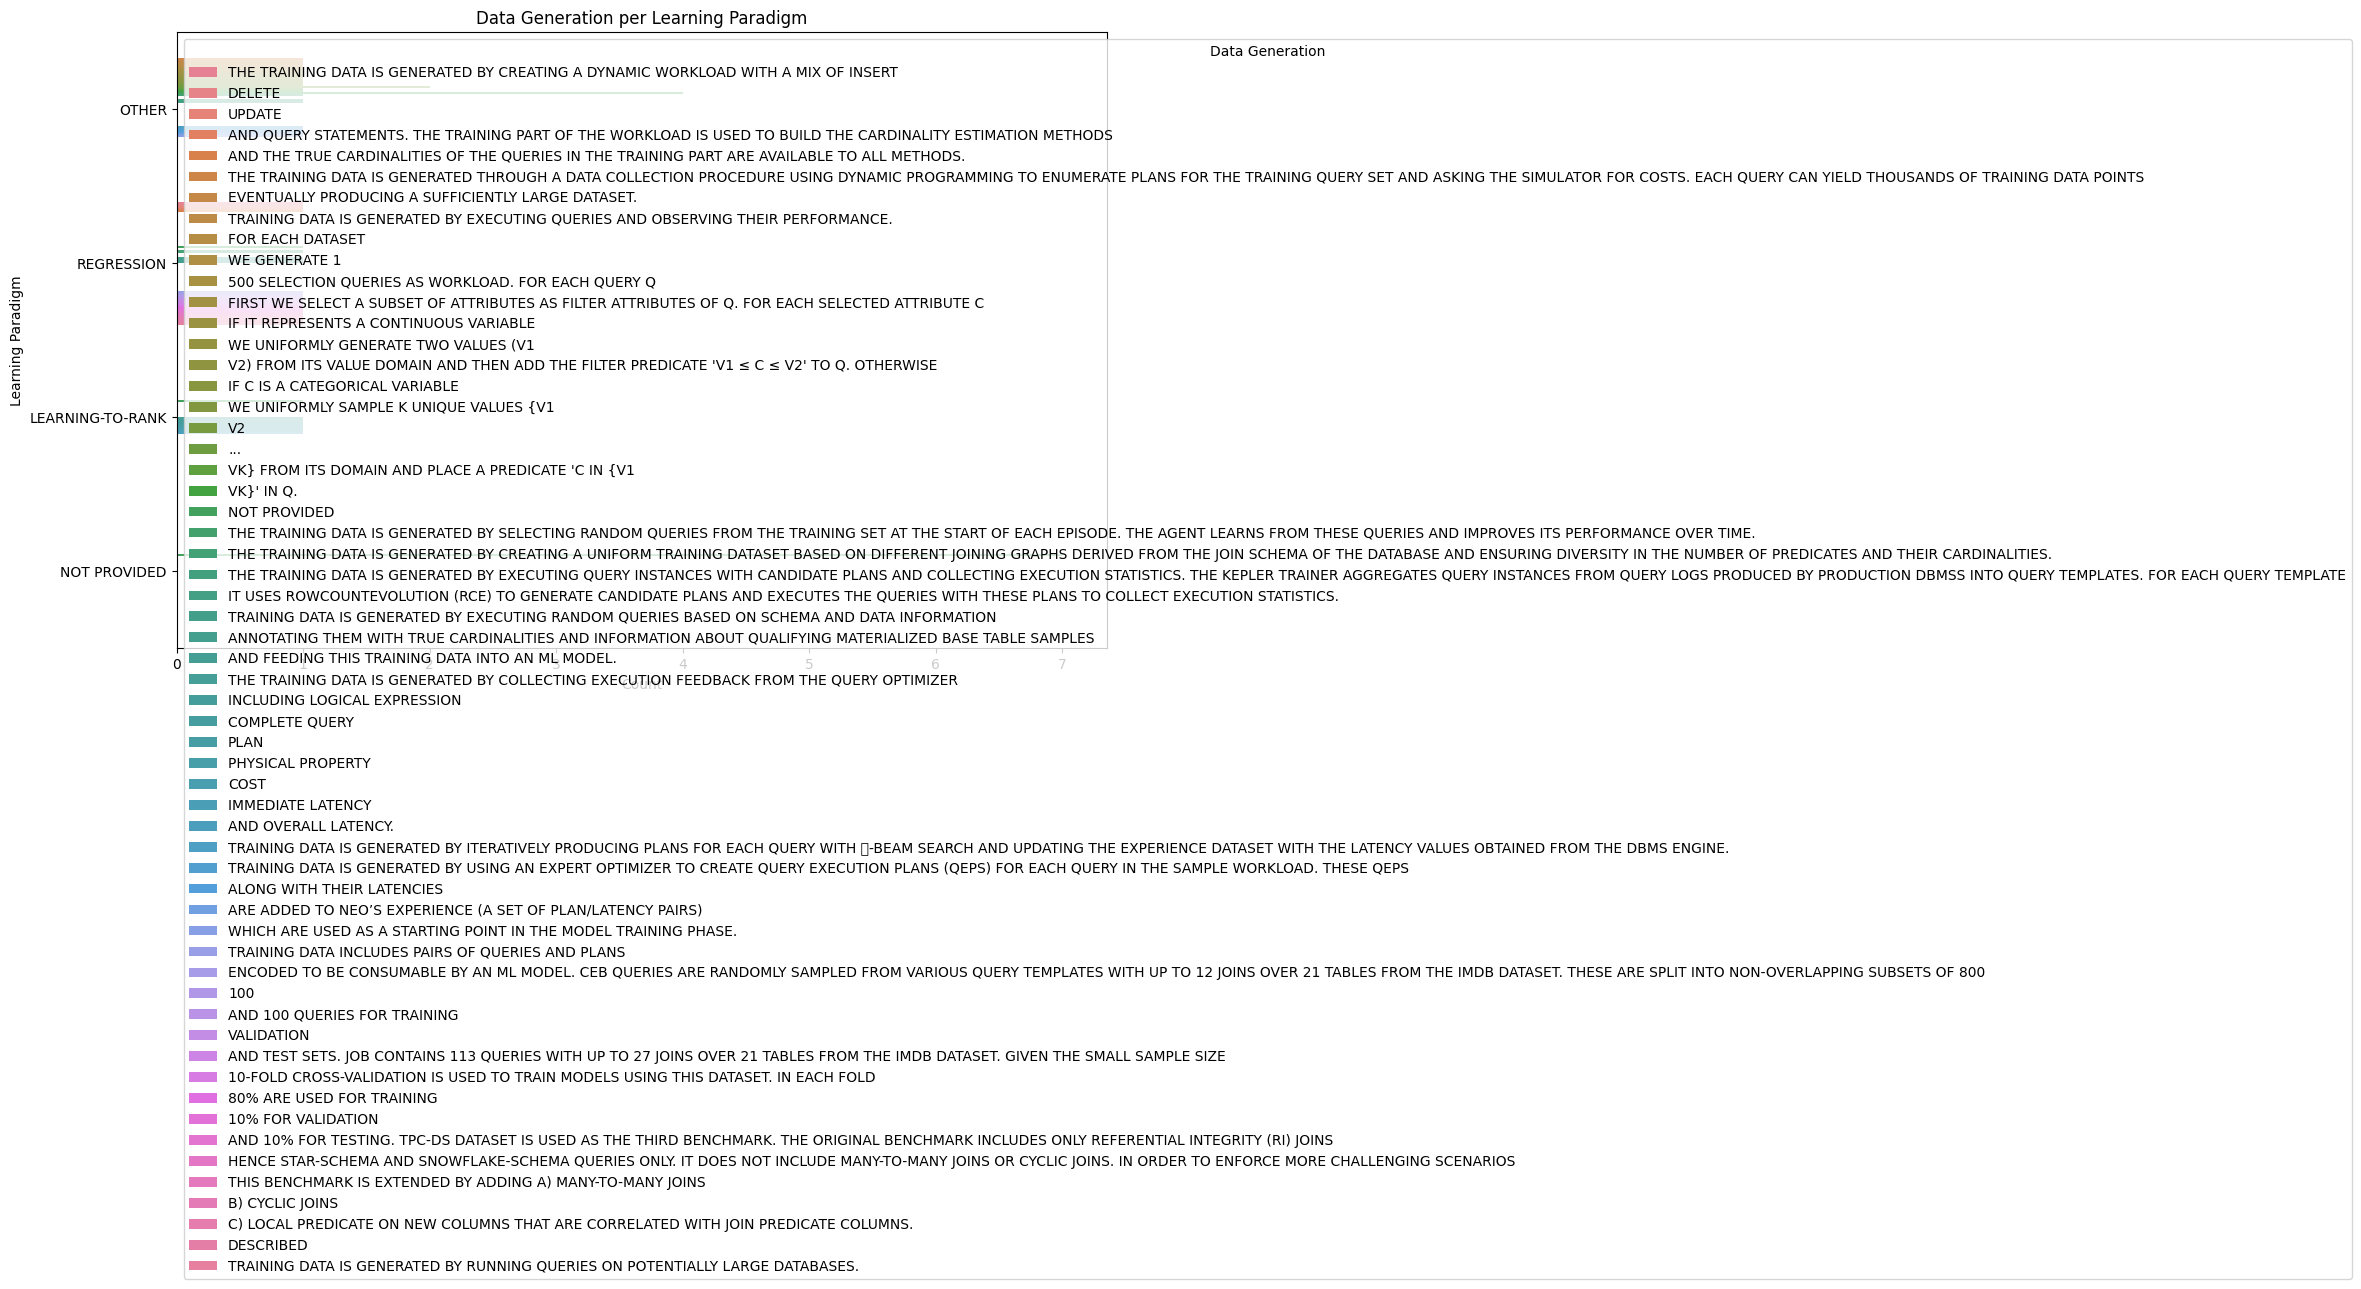

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Learning Paradigm",
    col_y="Data Generation"
)


### All Input Encoding Methods per Machine Learning Paradigm

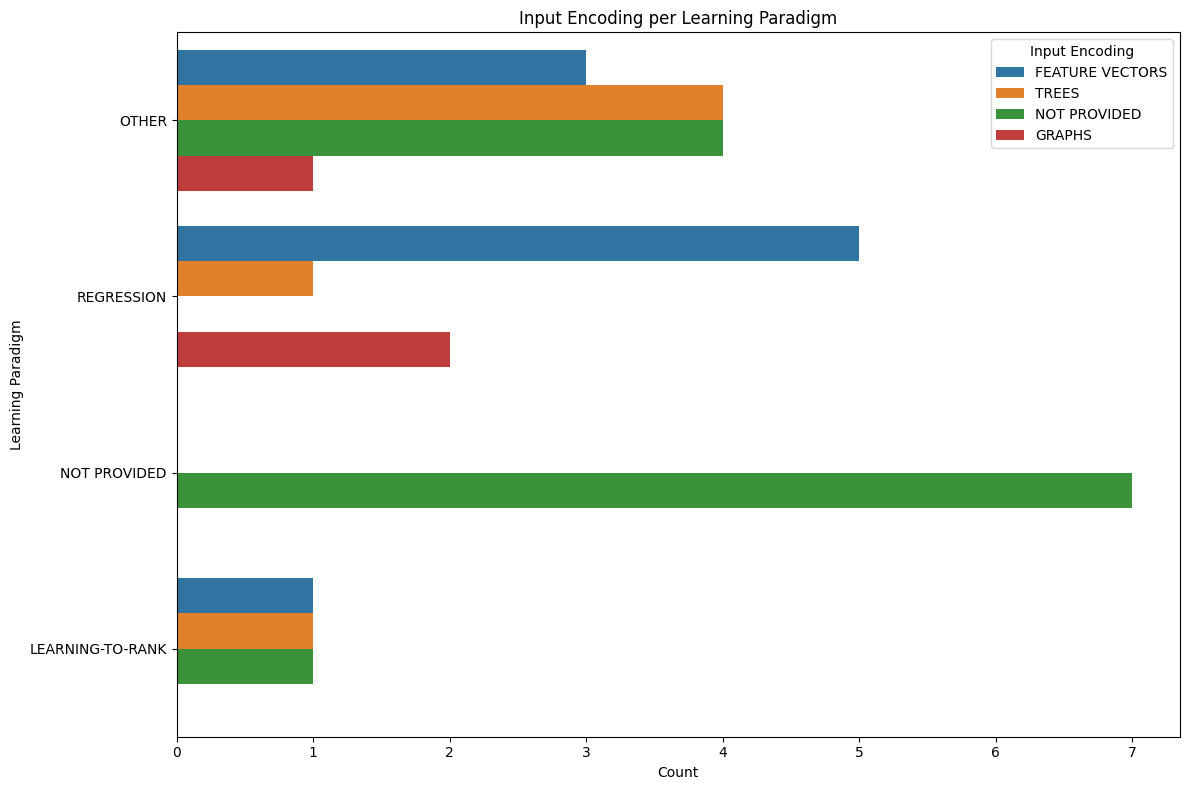

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Learning Paradigm",
    col_y="Input Encoding"
)


## Analysis on Training Data Generation

### Distribution of Training Data Generation Methods Over Time

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/2024216035.py:27: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/2024216035.py:27: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/Users/jhaha/Documents/GitHub/FullTextScreener/.env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


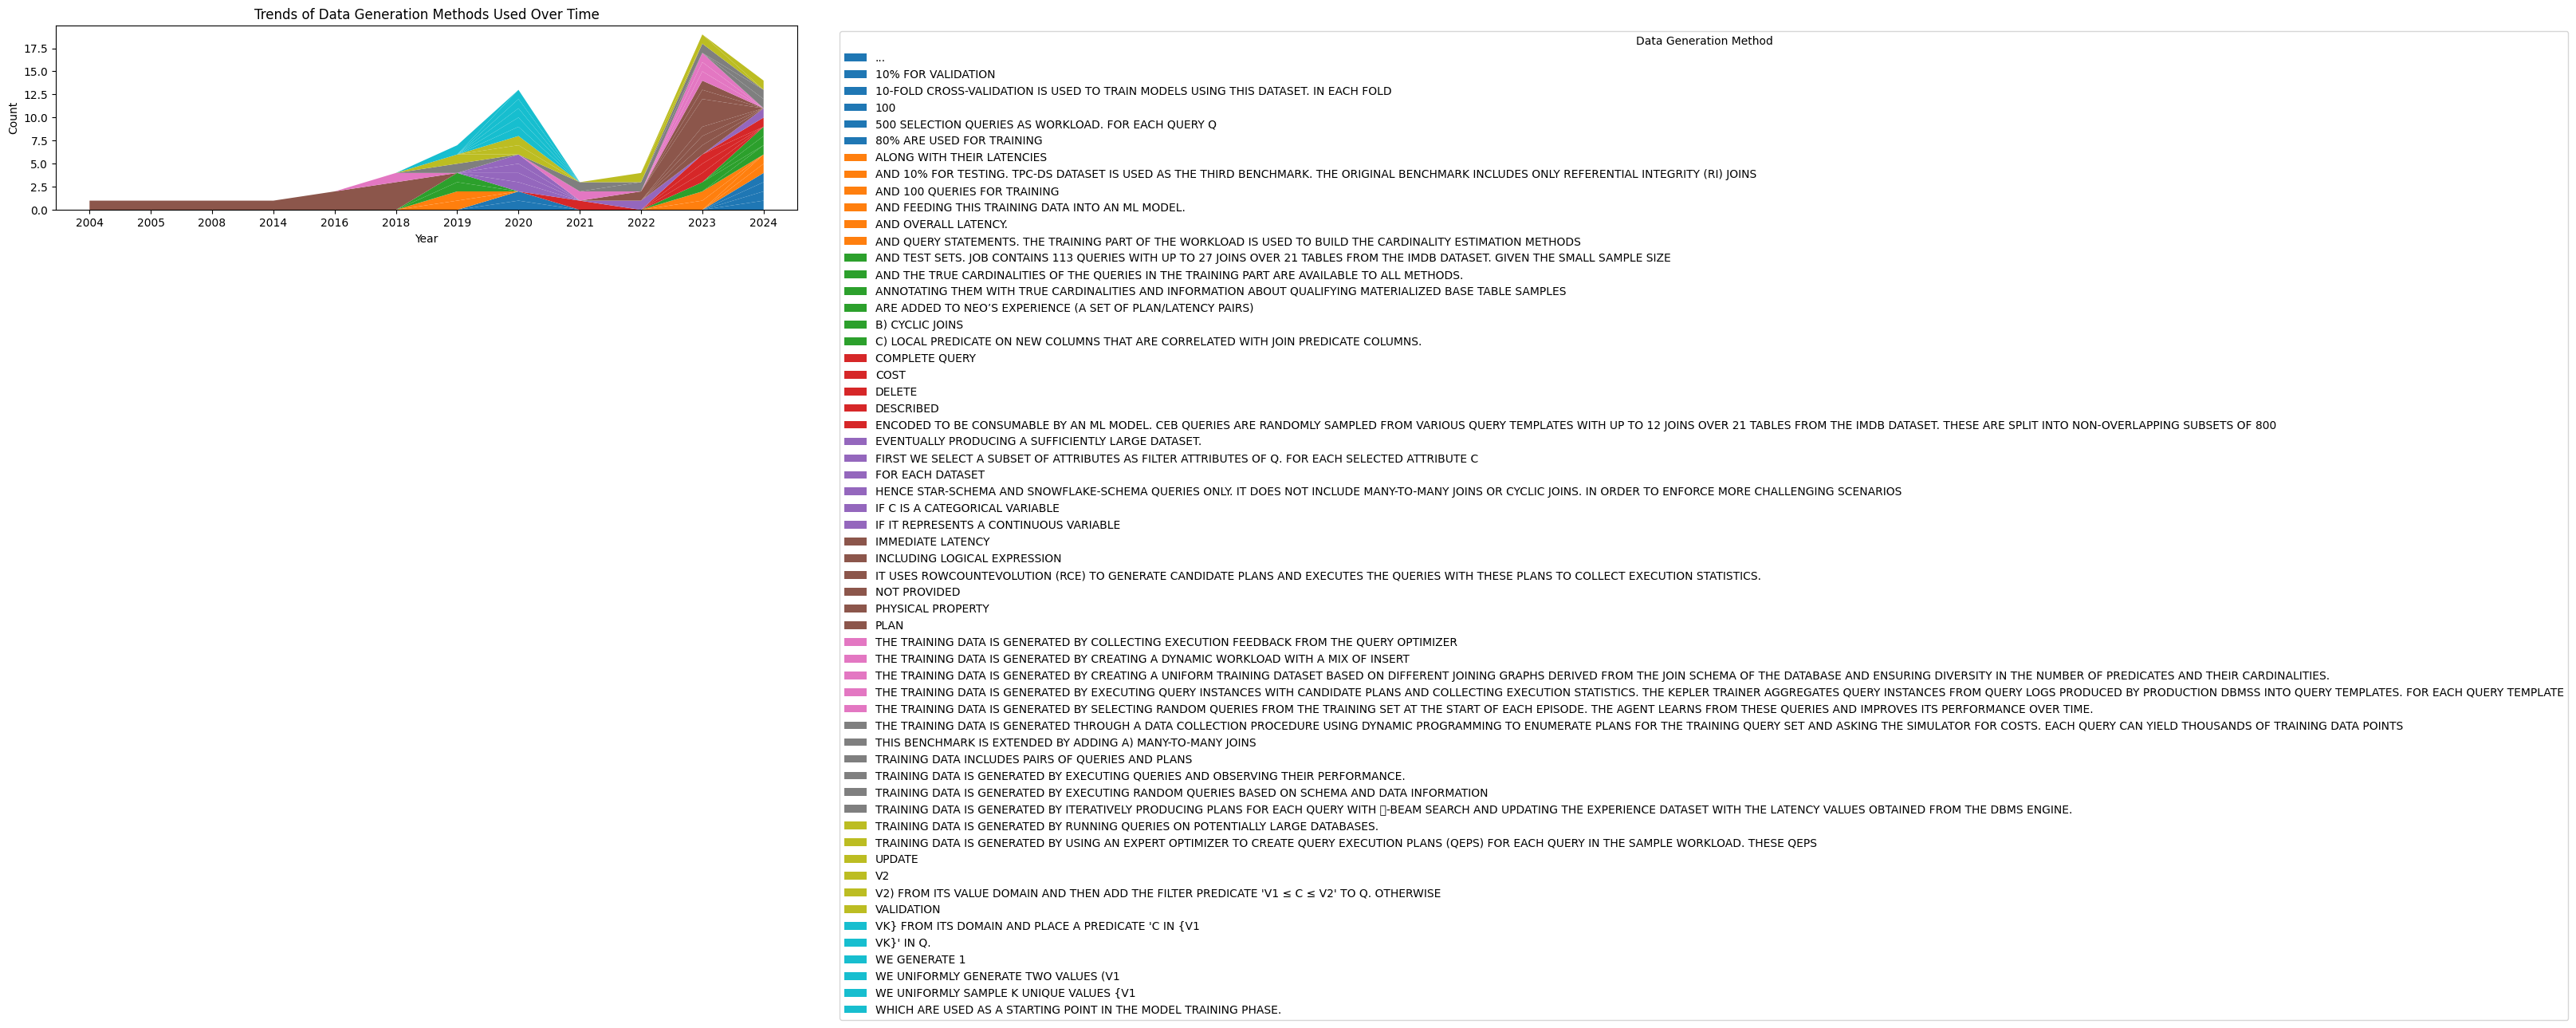

In [ ]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Data Generation_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Data Generation_', '') if x.startswith('Data Generation_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Data Generation Methods Used Over Time")
plt.legend(title="Data Generation Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Training Data Generation Methods

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3942134759.py:12: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3942134759.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/Users/jhaha/Documents/GitHub/FullTextScreener/.env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


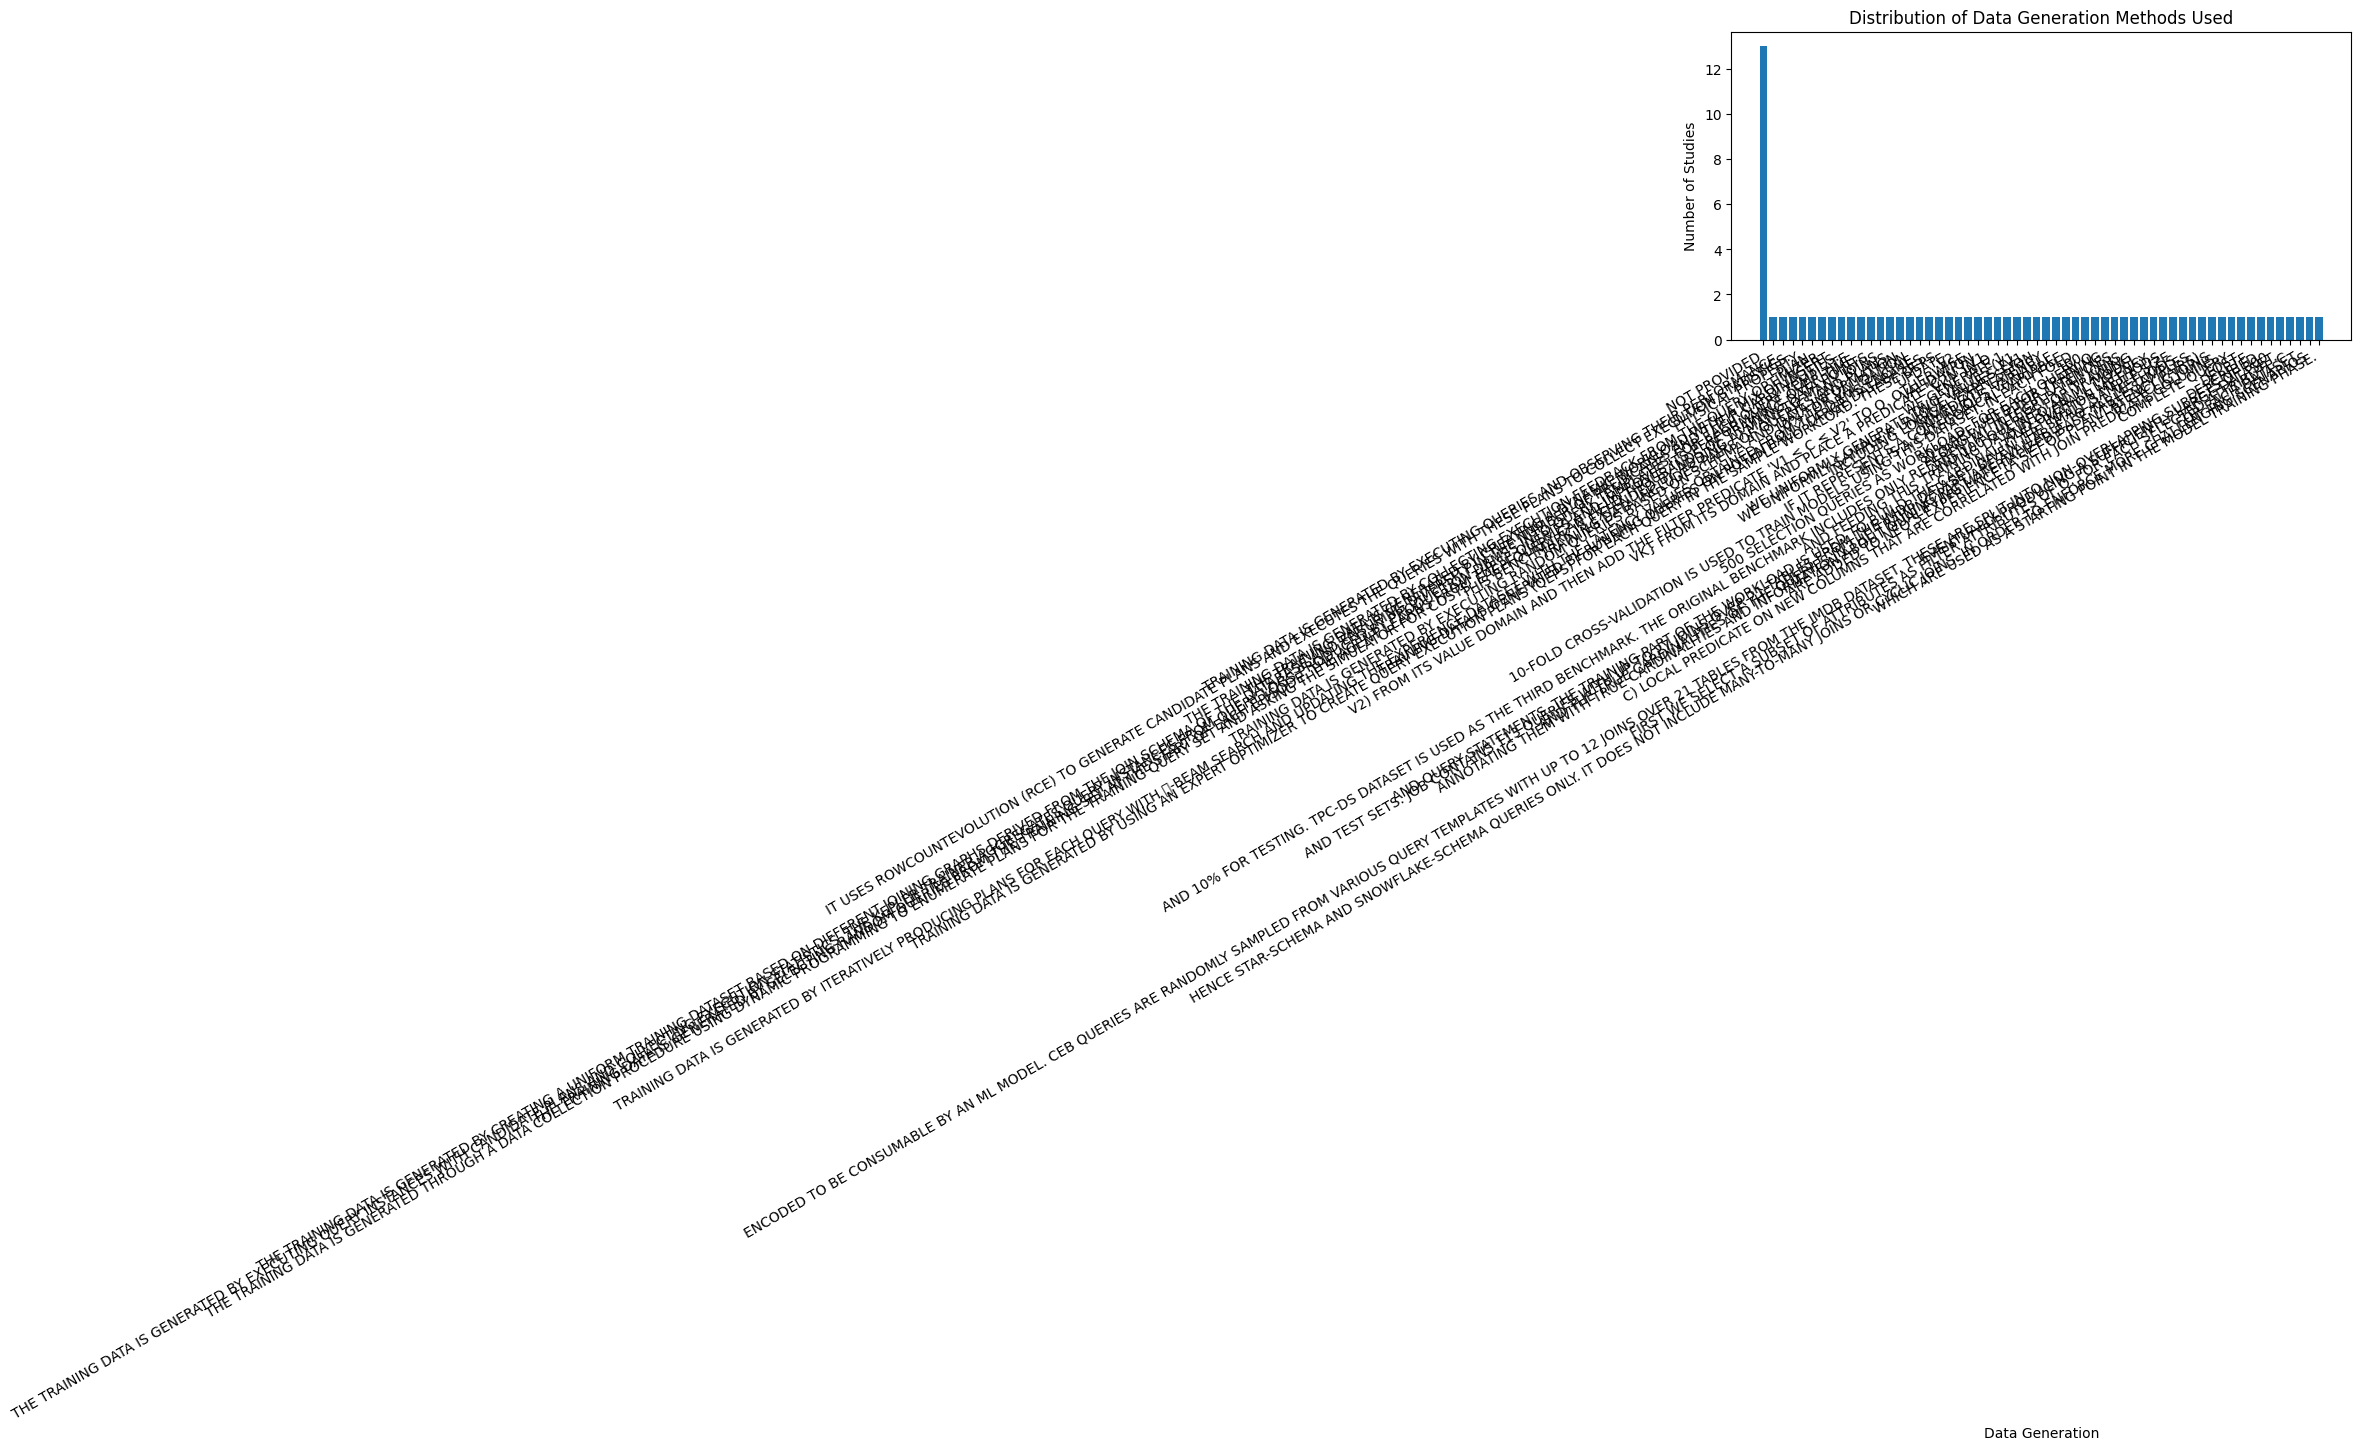

In [ ]:
plot_multilabel_distribution(answers_df_encoded, "Data Generation", "Distribution of Data Generation Methods Used")

### Comparing Data Generation Methods per Input Encoding Method

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/Users/jhaha/Documents/GitHub/FullTextScreener/.env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


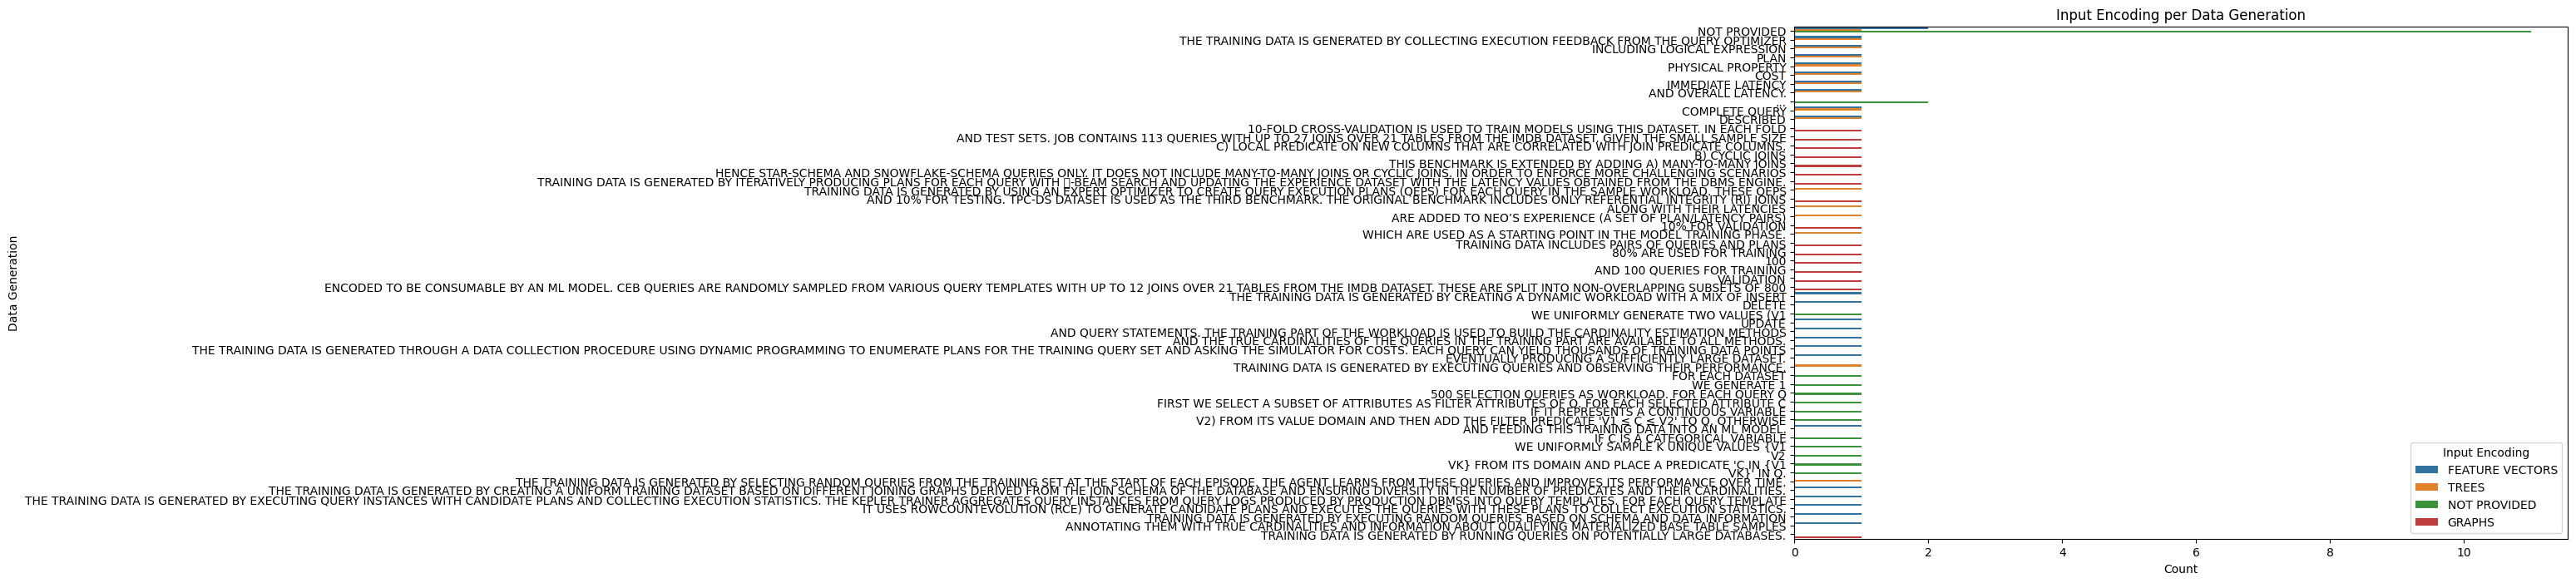

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Data Generation",
    col_y="Input Encoding"
)

### Data Generation Methods that have Uncertainty Evaluation

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/Users/jhaha/Documents/GitHub/FullTextScreener/.env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


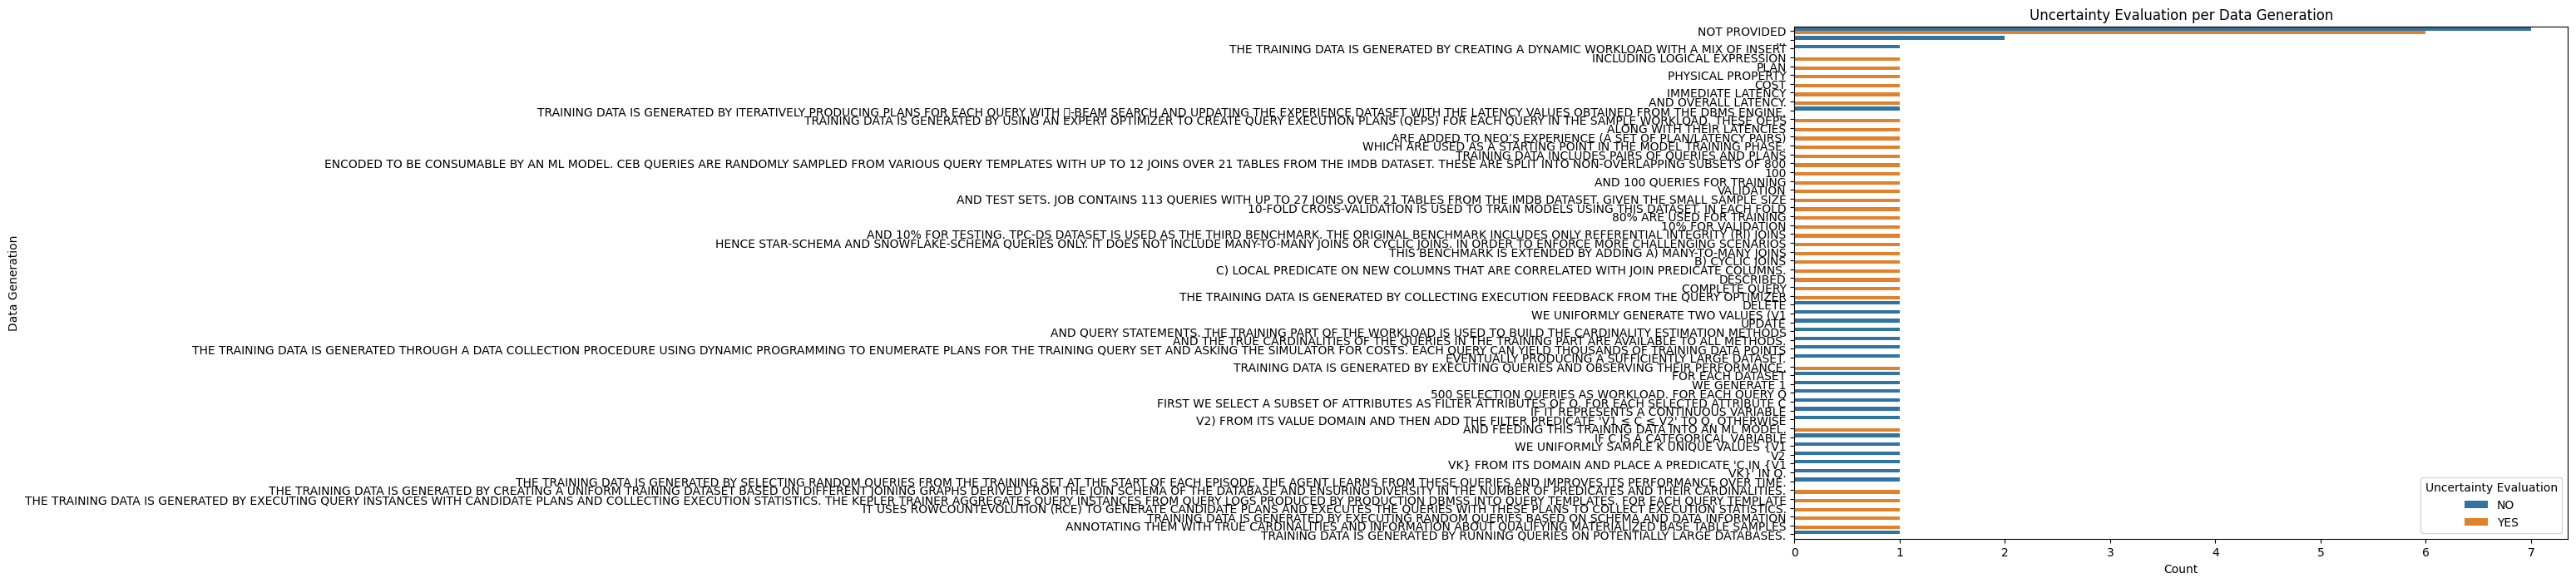

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Data Generation",
    col_y="Uncertainty Evaluation"
)

### Data Generation Methods that have OOD Evaluation

/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gk/1nl96v_d3v195hj5wckrd3xm0000gn/T/ipykernel_53221/3683687613.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/Users/jhaha/Documents/GitHub/FullTextScreener/.env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 120598 (\N{MATHEMATICAL ITALIC EPSILON SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


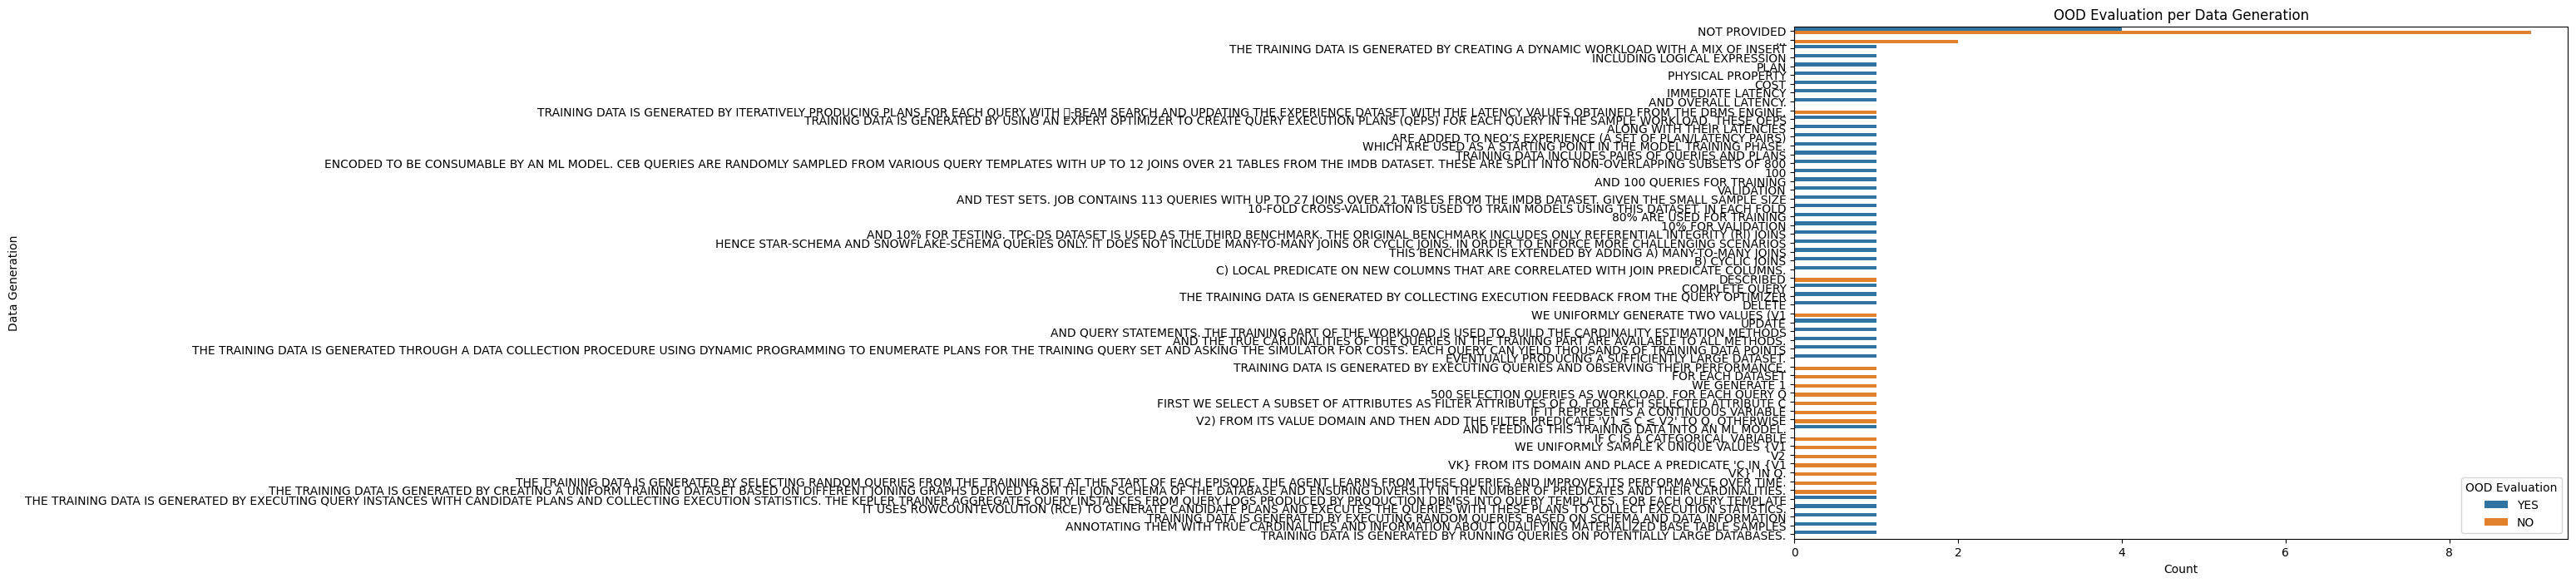

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Data Generation",
    col_y="OOD Evaluation"
)

## Analysis on Input Encoding

### Distribution of Task Type Over all Papers

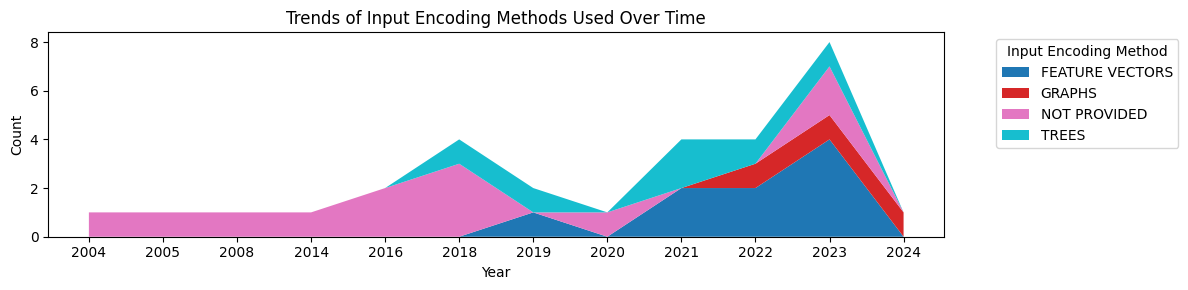

In [ ]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Input Encoding_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Input Encoding_', '') if x.startswith('Input Encoding_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Input Encoding Methods Used Over Time")
plt.legend(title="Input Encoding Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Distribution of Task Type Over all Papers Over Time

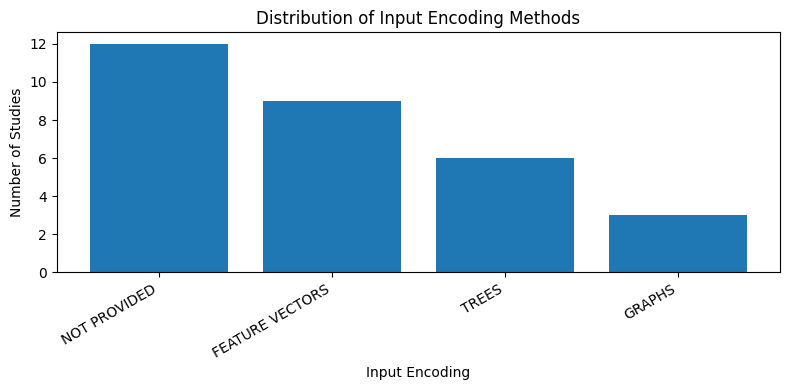

In [ ]:
plot_multilabel_distribution(answers_df_encoded, "Input Encoding", "Distribution of Input Encoding Methods")

### Uncertainty Evaluation Counts per Input Encoding

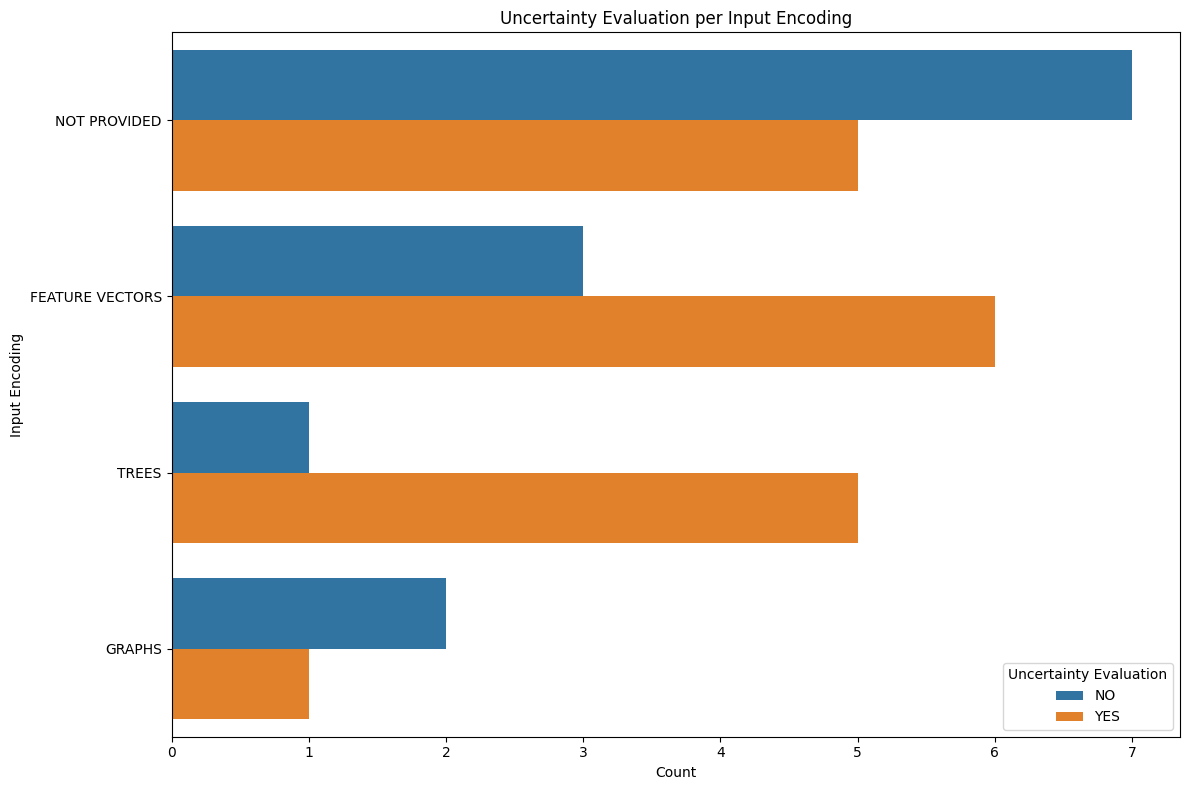

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Input Encoding",
    col_y="Uncertainty Evaluation"
)

### Out of Distribution Evaluation Counts per Input Encoding

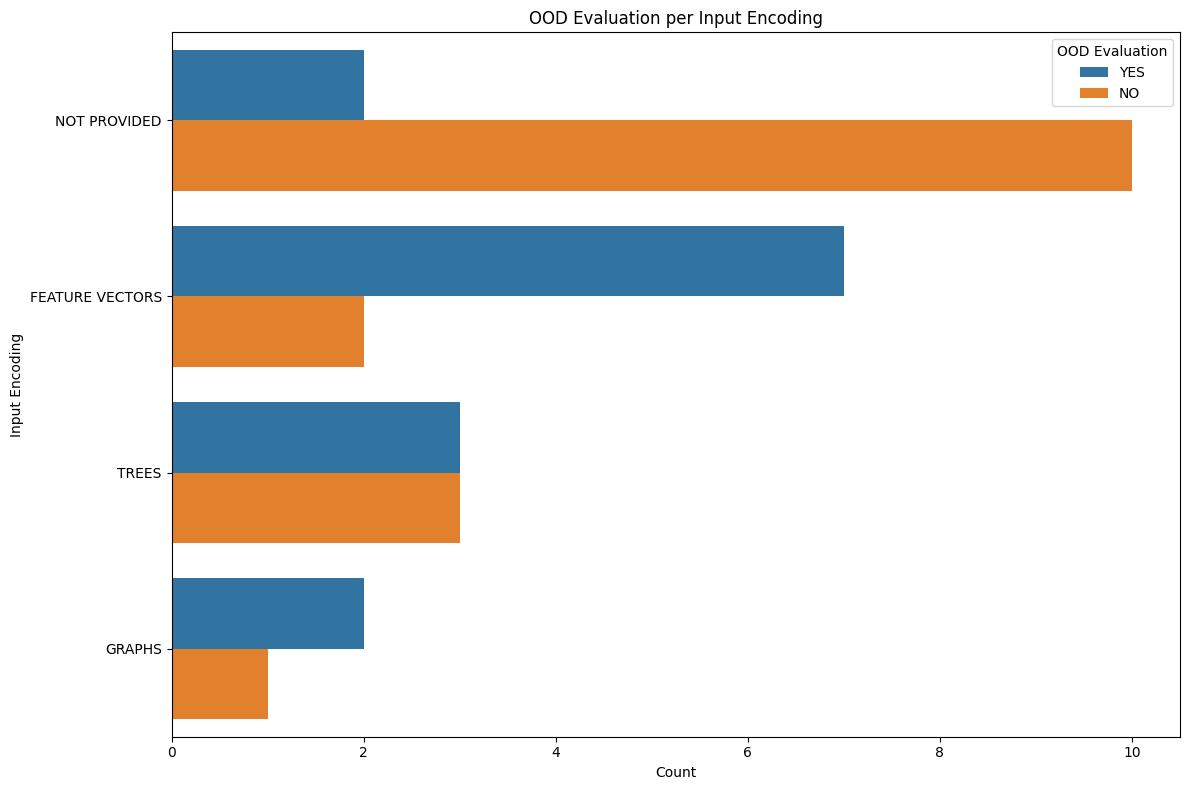

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Input Encoding",
    col_y="OOD Evaluation"
)

### Input Encoding Methods used per Model Architecture

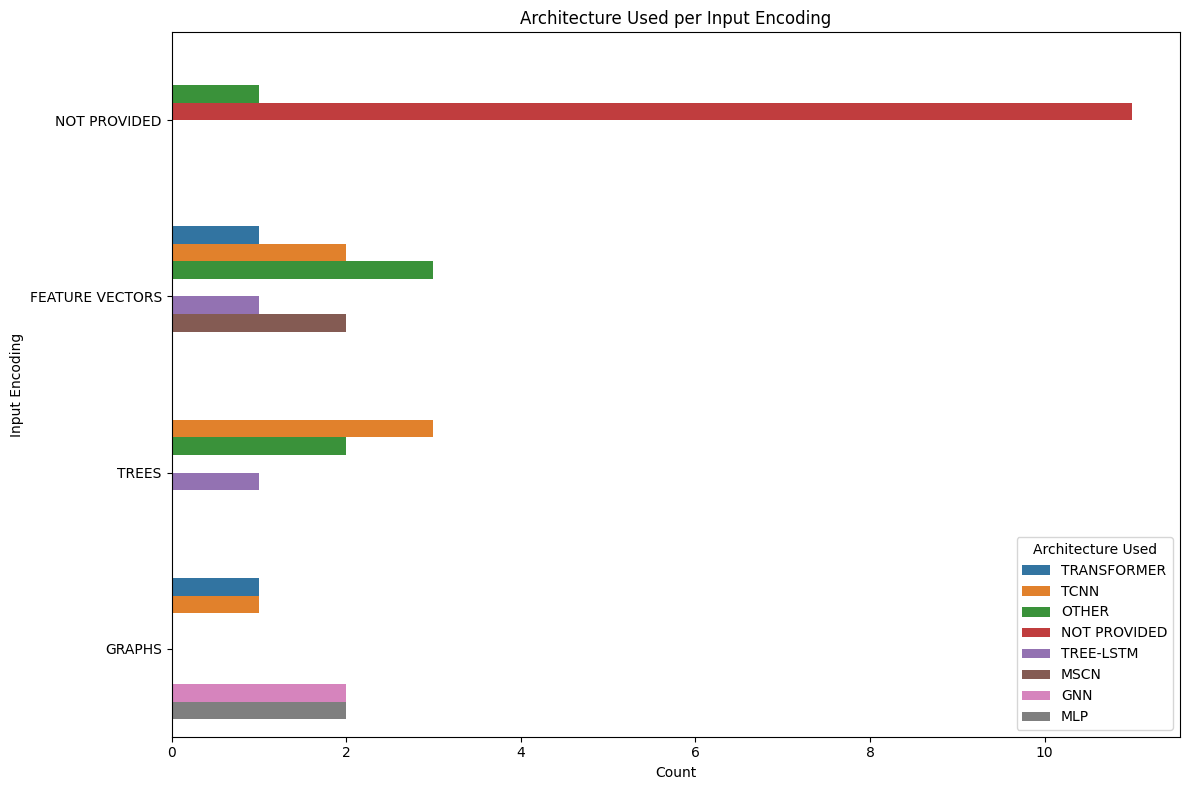

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Input Encoding",
    col_y="Architecture Used"
)

## Analysis on Uncertainty Evaluation

### Bar Plot of papers that have Uncertainty Evaluations

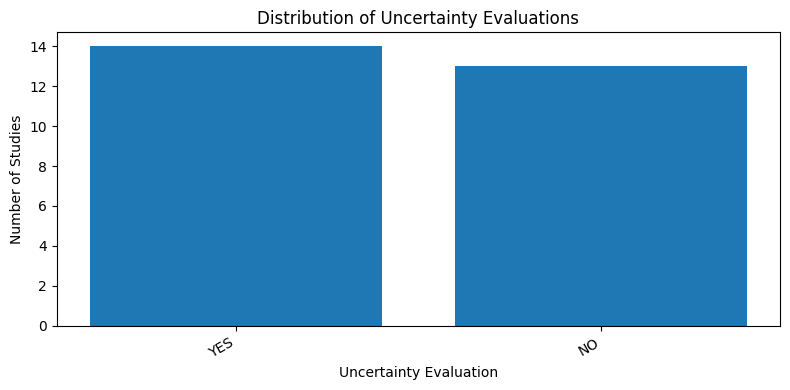

In [ ]:
plot_multilabel_distribution(answers_df_encoded, "Uncertainty Evaluation", "Distribution of Uncertainty Evaluations")

### Uncertainty Evaluations that also account Out of Distribution Evaluations

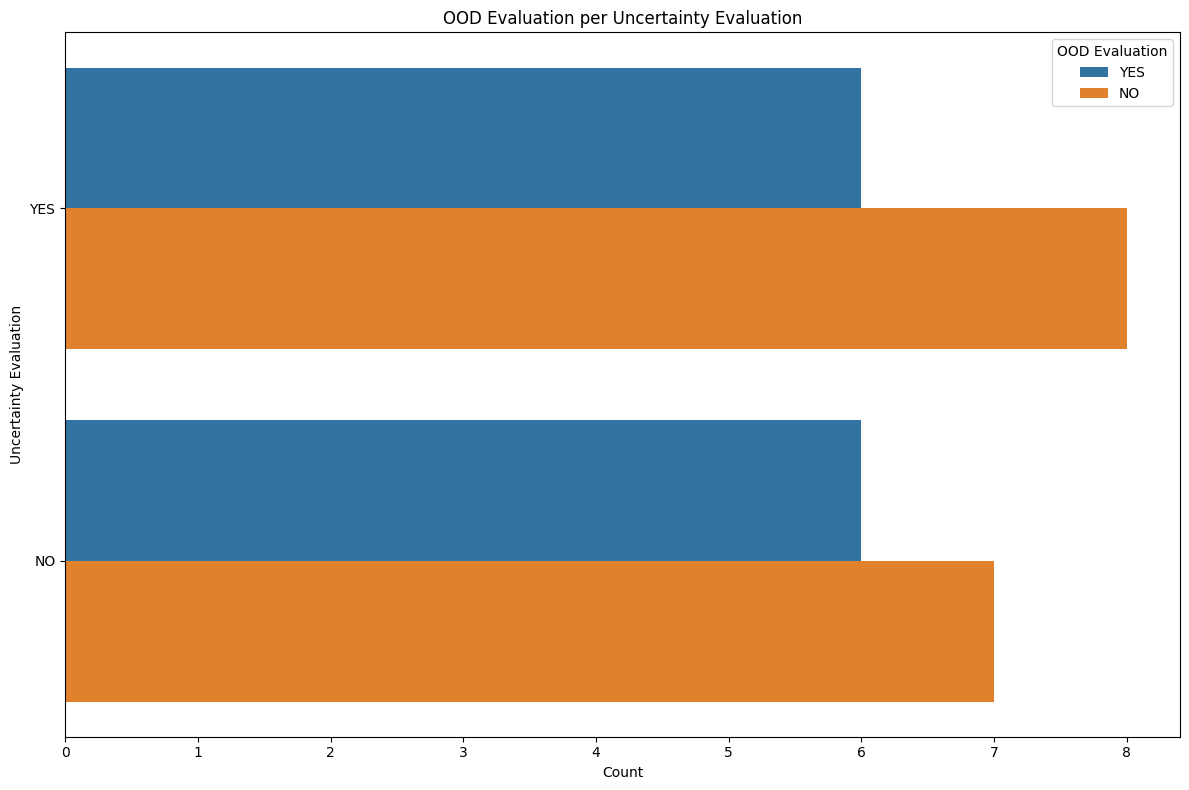

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Uncertainty Evaluation",
    col_y="OOD Evaluation"
)

### Uncertainty Evaluation Counts per Model Architecture

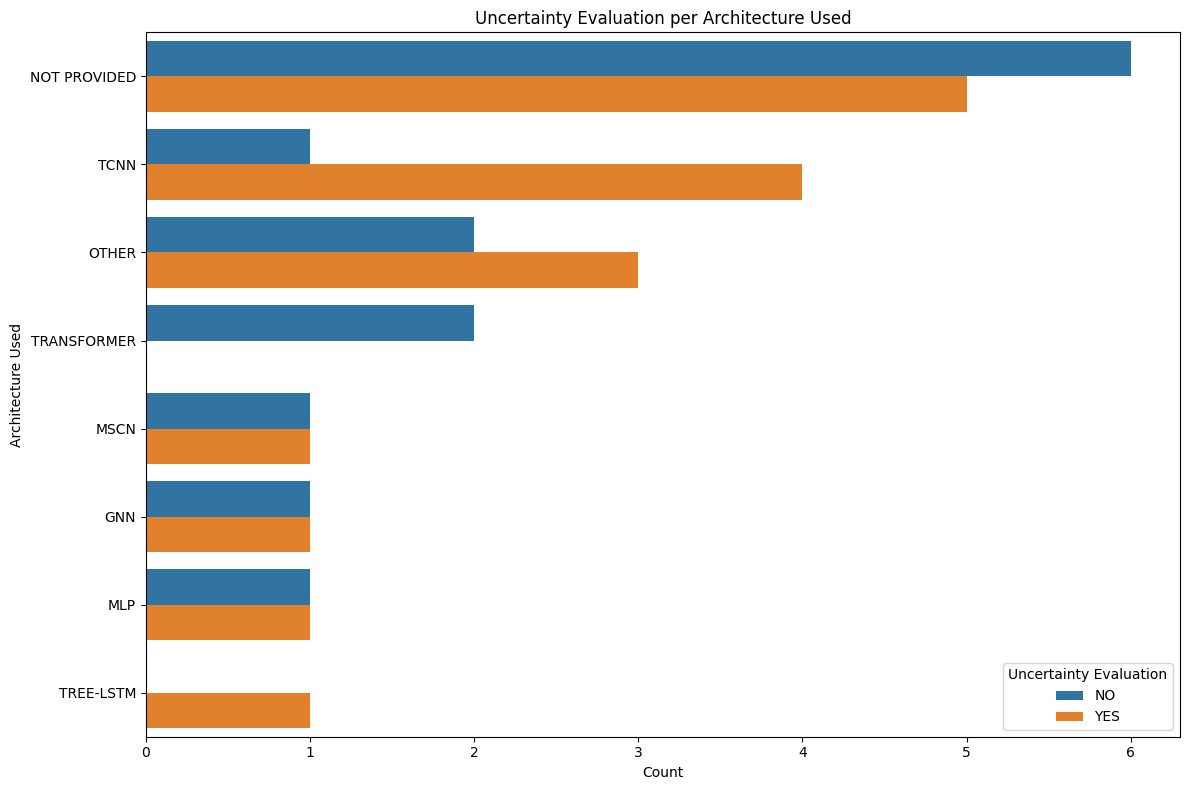

In [ ]:
plot_multilabel_relation_explode(
    df=answers_df,  
    col_x="Architecture Used",
    col_y="Uncertainty Evaluation"
)

## Analysis on Out of Distribution Evaluation

### Bar Plot of Training Data Generation Methods

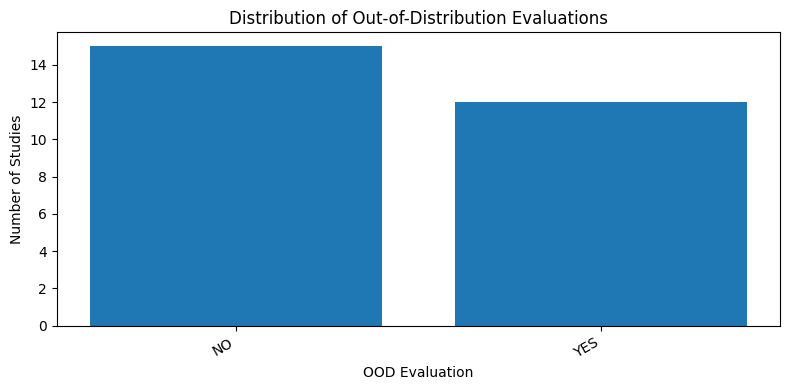

In [ ]:
plot_multilabel_distribution(answers_df_encoded, "OOD Evaluation", "Distribution of Out-of-Distribution Evaluations")

## Analysis on Model Architecture

### Distribution of Model Architectures Used Over Time

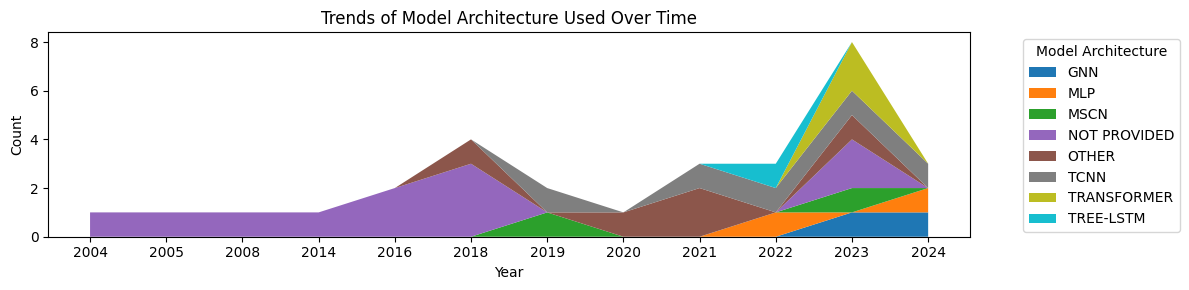

In [ ]:
target_cols = [col for col in answers_df_encoded.columns if col.startswith('Architecture Used_')]

time_series = answers_df_encoded[['Year'] + target_cols].copy()
time_series = time_series.groupby(by='Year').sum()
time_series.sort_values(by='Year', inplace=True)

time_series.rename(
    columns=lambda x: x.replace('Architecture Used_', '') if x.startswith('Architecture Used_') else x,
    inplace=True
)

# Prepare the data for the stackplot
years = time_series.index.values
stack_data = [time_series[col].values for col in time_series.columns]

# Generate a pastel color palette using the 'tab10' colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(time_series.columns))]

plt.figure(figsize=(12, 3))
plt.stackplot(years, stack_data, labels=time_series.columns, colors=colors)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Trends of Model Architecture Used Over Time")
plt.legend(title="Model Architecture", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Bar Plot of Model Architectures Used

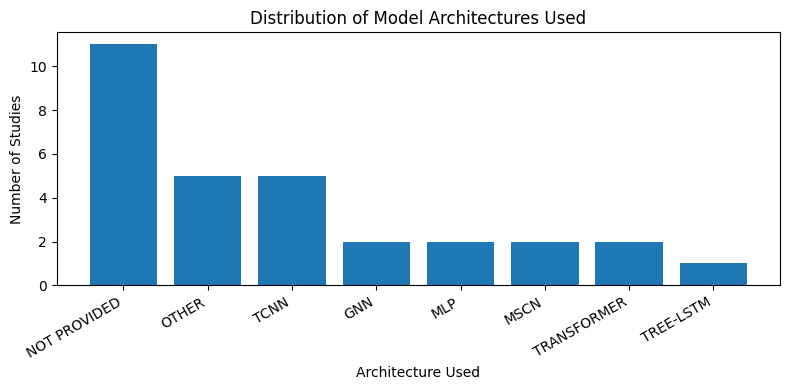

In [ ]:
plot_multilabel_distribution(answers_df_encoded, "Architecture Used", "Distribution of Model Architectures Used")